# 14 Winding R as a thermometer

Copper gets about 0.39% more resistive for every degree C. So in principle the servo already carries a
thermometer, its own winding, and `osc ident burst` already measures the winding's R. If that
reading were good enough, the firmware could track how hot the motor is with no extra part, and an
ident stage could measure how fast the motor heats and cools.

To find out, I ran 26 `osc ident burst` runs on the MG90 on rev 2A board #1, two minutes apart. Five
cold runs first (the anchor), then eight runs with the motor heated between them by a 40% open-loop
dither at about 0.42 A, then thirteen runs while it cooled with torque off. A 10K NTC taped to the
motor can was read before and after every run. The questions were:

1. Is R a usable thermometer, once the burst fit's R against V0 trade is taken out?
2. What thermal model fits, one node or two (winding, can, air), and what are its numbers?
3. How short could an ident thermal stage be and still pin the thermal resistance and time constant
   to 10-15%?
4. Does V/I at the current limit move with the temperature the way R does, with the rail, or with V0?

Two hours after that evening run I left the same servo resting overnight and ran a burst every 30
minutes, 20 runs with nothing heating the motor (sections 9 to 12). The night changed several of the
evening's answers, so the summary below is what the two say together.

If you are short on time, here is the whole answer up front:

- **At rest, R repeats to 0.7% once the fit's R-V0 trade is taken out.** Overnight, the R that
  `osc ident` printed scattered 2.1% (4.856 +/- 0.104 ohm), and nearly all of it was the fit trading
  R against V0 along a line of -2.18 ohm/V. Refitting every run with V0 held at one reference leaves
  0.033 ohm, 0.69%, about 1.8 C of copper, which is the fit's own error. The rail, the clock, the rung
  set and the spacing of the runs add nothing that clears the noise.
- **The evening's -5% "drift" was a warm anchor.** Read against the night's R at rest, the cold
  anchor sat 14 to 31 C over its can and the last cool runs 2 C. A V0 offset between the sessions
  accounts for at most 6 to 8 C of the anchor's excess.
- **The winding runs well above the can and comes back slowly.** During the heat, at about 1 W, it
  reads 22 to 53 C over the can. In the cool its excess decays with a time constant of 720 +/- 157 s,
  while the can settles in about 110 s.
- **No two-node model fits both the can and R.** With the heat into the winding (on the rotor, behind
  the air gap), a fit that follows the can misses R by 12 to 14 C rms, and one that follows R misses
  the can by 2.6 C. The slow decay would need a winding heat capacity of 10 to 14 J/C, several times a
  rotor of a few grams. Something holds R up after running, a third thermal mass or a part of R that
  is not temperature, and this data cannot say which.
- **The temperature coefficient is not measured.** The night's can moved only 2.1 C, and it moved
  together with the rail and the clock.
- **The stage lengths of section 7 rest on section 6's two-node fit**, which section 12 rejects. They
  need redoing with a model that fits.
- **V/I at the current limit is R plus 1.80 ohm per volt of the free fit's V0.** Those two account for
  it to 0.024 ohm rms. It follows the temperature through R, and the rail adds nothing on top. It
  follows V0 because the burst pins its line near 0.48 A, where the top rung ends, and V/I is read at
  0.25 A, half way down to zero current.

## Picking a rig

One dataset, `mg90-a__dev-v006-2A__2s__thermal`. Its burst captures do not carry a `sense` block the
way a TEL recording's meta.json does, so the board cannot be identified from the data. The bench log
says rev 2A board #1, so I name it here, and the table below is what that choice means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import lfilter
from IPython.display import display

import oscnb
from oscnb import boards, servos, wavefit as wf

# The burst captures carry no sense block, so the board cannot be read off the data the way
# every other dataset does it. The bench log names it: rev 2A board #1 with the MG90 on it.
DS = oscnb.datasets.ROOT / "mg90-a__dev-v006-2A__2s__thermal"
board, servo = boards.BOARDS["dev-v006-2A"], servos.SERVOS["mg90-a"]
rig = oscnb.Rig(board, servo).show()

SC = wf.Scales.of(board)                     # what one count is worth, the way osc ident reads it
I_LIM = 280 * SC.amps_per_count              # the servo's current limit, where V/I is read
ALPHA_CU = 0.0039                            # copper, per degree C
RUNS = pd.read_csv(DS / "runs.csv")          # one row per osc ident burst run


def ntc_c(raw):
    # 10K 3950 NTC to GND under a 10K pull-up to 3V3, the driver script's own conversion
    return 1 / (1 / 298.15 + np.log(raw / (4095 - raw)) / 3950) - 273.15


RUNS["can_before"] = ntc_c(RUNS.ntc_raw_before)
RUNS["can_after"] = ntc_c(RUNS.ntc_raw_after)
print(f"{len(RUNS)} runs: " + ", ".join(f"{p} {n}" for p, n in RUNS.phase.value_counts().sort_index().items()))
print(f"rail {RUNS.rail_v.min():.2f} .. {RUNS.rail_v.max():.2f} V at rest before each run, "
      f"current limit {I_LIM * 1e3:.0f} mA")

Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. FLOORS UNVERIFIED: the 2A build ships 160/160 ticks. nb10 sec 8 derives 132 for the current at 1% and keeps 160 for the terminals, pending a ladder th

value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from (UNVERIFIED)                  % duty                 13.3333
                 voltage settled from (UNVERIFIED)                  % duty                 13.3333
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800

26 runs: A 5, B 8, C 13
rail 7.84 .. 8.03 V at rest before each run, current limit 253 mA


## 1. The run

The driver script (`captures/winding-r/heatcool2.py` in the bringup repo) did this, all at mid travel:

- **A, cold anchor.** Five burst runs about 37 s apart, after the can had stopped cooling (two reads two
  minutes apart within 0.15 C).
- **B, heat.** Eight times, about 100 s of a +/-40% open-loop dither, then one burst run. The dither
  flips direction every poll, so the winding keeps driving against its own back-EMF and the current
  sits near the limit. The limit was raised to 500 counts in RAM for the heater only. Every burst run
  itself ran under the usual 280.
- **C, cool.** Torque off, one burst run every 120 s for 26 minutes.

Each burst run takes about 18 s. The heat stops for it, so the motor cools a little through every run.

,start_s,end_s,polls,i_rms_A,|i| mean A,signed mean A
0,309.63,429.17,2812,0.419,0.418,-0.000
1,448.15,549.17,2421,0.420,0.419,-0.002
2,567.19,669.16,2412,0.420,0.419,-0.001
3,688.86,789.16,2402,0.419,0.418,-0.001
4,808.68,909.18,2381,0.418,0.417,-0.002
5,928.50,1029.18,2352,0.418,0.417,-0.003
6,1048.39,1149.17,2363,0.418,0.416,-0.002
7,1168.46,1269.18,2413,0.418,0.417,-0.002


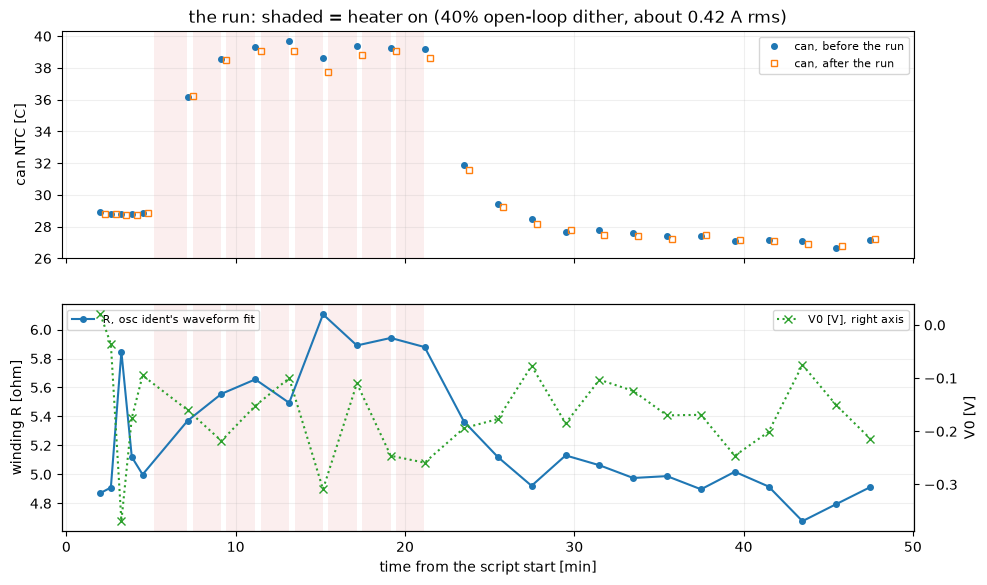

In [2]:
# Every heater poll: the firmware's current reading at 25 Hz while the dither runs.
H = pd.read_csv(DS / "heater.csv.gz")
H["amps"] = H.i_hat_counts * board.a_per_count
seg = (H.t_s.diff() > 3).cumsum()             # a gap over 3 s is a burst run between two heat windows
HEAT = pd.DataFrame([{"start_s": g.t_s.iloc[0], "end_s": g.t_s.iloc[-1],
                      "polls": len(g), "i_rms_A": np.sqrt((g.amps ** 2).mean()),
                      "|i| mean A": g.amps.abs().mean(), "signed mean A": g.amps.mean()}
                     for _, g in H.groupby(seg)])
display(HEAT.round(3))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
for _, w in HEAT.iterrows():
    for ax in (a1, a2):
        ax.axvspan(w.start_s / 60, w.end_s / 60, color="tab:red", alpha=0.08, lw=0)
a1.plot(RUNS.t_s / 60, RUNS.can_before, "o", ms=4, label="can, before the run")
a1.plot((RUNS.t_s + RUNS.burst_s) / 60, RUNS.can_after, "s", ms=4, mfc="none", label="can, after the run")
a1.set_ylabel("can NTC [C]")
a1.legend(fontsize=8)
a2.plot(RUNS.t_s / 60, RUNS.wave_r_ohm, "o-", ms=4, label="R, osc ident's waveform fit")
a2.set_ylabel("winding R [ohm]")
a2b = a2.twinx()
a2b.plot(RUNS.t_s / 60, RUNS.v0_v, "x:", color="tab:green", label="V0 [V], right axis")
a2b.set_ylabel("V0 [V]")
a2.legend(loc="upper left", fontsize=8)
a2b.legend(loc="upper right", fontsize=8)
a2.set_xlabel("time from the script start [min]")
a1.set_title("the run: shaded = heater on (40% open-loop dither, about 0.42 A rms)")
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()

**What you are looking at.** The top table is the heater, one row per heat window, from the firmware's
current reading polled at 25 Hz. The plot shows the can before and after every run (top) and the R and
V0 that `osc ident` printed (bottom). Shaded bands are the heater.

The heater is very steady, 0.418 to 0.420 A rms in every window, with no net direction. The can
climbs 7.4 C in the first two minutes and levels near 39 C. From the third heat window on, it drops
0.2 to 0.9 C across each 18 s burst run, which a single lumped node cannot do while also rising that
fast (section 6).

Run 9 sticks out. Its can reads 38.2 C before the run, a full degree under its neighbours, with the
same heater current as every other window. I have no explanation for it. It shows up again in the
model fit, and section 6 fits with and without it.

The R that `osc ident` printed scatters 4.87 to 5.85 ohm across the five cold runs, while V0 swings
-0.37 to +0.02 V. That is the problem the next three sections deal with.

## 2. The fit, ported

The burst's whole-waveform fit lives in Rust, in osc-ident `exp::wavefit`. It has no switch to hold V0,
so I ported it to Python as `oscnb/wavefit.py`, line for line. The model steps one PWM period every
0.25 us, ON and OFF phases with the bridge and shunt resistances, a rotor that spins up from rest
using the class's back-EMF and inertia priors, and the shunt amplifier's lag. It fits five parameters
to the shunt samples of the 16 captures that start from rest:

- $R$, the winding resistance, in ohm
- $L$, the winding inductance
- $V_0$, a fixed voltage drop (brush drop and the like)
- $\tau_a$, the amplifier lag, and $\delta$, how late the samples sit

Before trusting the port with anything new, it has to give back what `osc ident` printed for the same
captures, with nothing held. It runs ident's own sequence: a pooled fit, every capture alone, the
captures under 85% of the median R set aside, and a pooled fit again.

In [3]:
# Load every run's 24 captures and split them the way osc ident does. Only the 16 captures
# that step from rest feed the waveform fit, the 8 from a hold are its V0 control.
def load_run(k):
    paths = sorted((DS / "burst" / RUNS.capture[k]).glob("burst-*.csv.gz"),
                   key=lambda p: int(p.name.split("-")[1].split(".")[0]))
    caps = [wf.Capture.read(p, int(p.name.split("-")[1].split(".")[0])) for p in paths]
    return wf.Run.build(caps, SC)


RUN = {k: load_run(k) for k in RUNS.k}

# osc ident's own sequence with nothing held: pooled fit, each capture alone, set aside the
# captures under 85% of the median R, pooled again.
FREE = {}
for k, run in RUN.items():
    fit, each = run.fit_like_ident()
    keep = set(each["index"][~each.set_aside])
    FREE[k] = dict(fit=fit, each=each, vi=run.v_over_i(fit.p, I_LIM, keep))

par = pd.DataFrame({
    "R here": [FREE[k]["fit"].p["r"] for k in RUNS.k], "R osc": RUNS.wave_r_ohm,
    "V0 here": [FREE[k]["fit"].p["v0"] for k in RUNS.k], "V0 osc": RUNS.v0_v,
    "L here": [FREE[k]["fit"].p["l_mh"] for k in RUNS.k], "L osc": RUNS.l_mh,
    "V/I here": [FREE[k]["vi"] for k in RUNS.k], "V/I osc": RUNS.v_over_i_ohm,
    "set aside": [int(FREE[k]["each"].set_aside.sum()) for k in RUNS.k],
    "tau_a us": [FREE[k]["fit"].p["tau_a"] for k in RUNS.k]}, index=RUNS.k)
display(par.round(3).T)
for q in ("R", "V0", "L", "V/I"):
    d = (par[f"{q} here"] - par[f"{q} osc"]).abs()
    print(f"{q:>4}: port against osc ident, median |diff| {d.median():.4f}, worst {d.max():.4f} (run {d.idxmax()})")

k,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
R here,4.870,4.909,5.819,5.090,4.999,5.370,5.556,5.658,5.494,6.101,...,5.105,5.064,4.977,4.988,4.895,5.050,4.918,4.678,4.795,4.914
R osc,4.871,4.909,5.847,5.120,4.999,5.370,5.556,5.656,5.494,6.105,...,5.131,5.063,4.975,4.988,4.897,5.018,4.916,4.677,4.795,4.912
V0 here,0.020,-0.036,-0.359,-0.159,-0.095,-0.160,-0.218,-0.153,-0.100,-0.308,...,-0.173,-0.105,-0.125,-0.171,-0.168,-0.262,-0.202,-0.075,-0.151,-0.215
V0 osc,0.020,-0.036,-0.369,-0.175,-0.095,-0.160,-0.218,-0.152,-0.100,-0.309,...,-0.185,-0.103,-0.124,-0.170,-0.169,-0.246,-0.201,-0.075,-0.151,-0.214
L here,0.719,0.736,0.817,0.770,0.754,0.783,0.817,0.767,0.787,0.821,...,0.780,0.743,0.769,0.773,0.780,0.782,0.781,0.748,0.755,0.796
L osc,0.720,0.736,0.816,0.774,0.754,0.783,0.817,0.766,0.787,0.821,...,0.783,0.744,0.768,0.773,0.780,0.778,0.781,0.747,0.755,0.796
V/I here,5.626,5.417,5.093,5.133,5.301,5.394,5.389,5.668,5.796,5.563,...,5.035,5.345,5.126,5.008,4.885,4.705,4.811,5.051,4.874,4.732
V/I osc,5.625,5.417,5.081,5.102,5.301,5.394,5.389,5.669,5.796,5.560,...,5.012,5.352,5.128,5.008,4.883,4.736,4.812,5.051,4.874,4.733
set aside,0.000,0.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,...,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000
tau_a us,0.301,0.300,0.326,0.300,0.300,0.300,0.300,0.300,0.300,0.300,...,0.300,0.300,0.300,0.300,0.300,0.300,0.300,0.300,0.300,0.300


   R: port against osc ident, median |diff| 0.0017, worst 0.0319 (run 21)
  V0: port against osc ident, median |diff| 0.0007, worst 0.0164 (run 21)
   L: port against osc ident, median |diff| 0.0004, worst 0.0041 (run 3)
 V/I: port against osc ident, median |diff| 0.0013, worst 0.0314 (run 21)


**What you are looking at.** The port's numbers against the ones `osc ident` printed, per run.

The median difference in R is 0.002 ohm. The worst is 0.032 ohm on run 21 (0.6%), where the robust
solvers settle a little differently. L agrees to 0.004 mH and V/I at the limit to 0.03 ohm. That is
close enough to use the port for the rest.

One thing in the table to note. The amplifier lag $\tau_a$ sits on its lower bound of 0.30 us in
nearly every run, here and in the Rust fit. I checked four runs with the bound dropped to 0.01 us,
and R moved by under 0.04%. So the bound does not move R.

## 3. R and V0 trade

Inside one burst, R and V0 cannot be told apart well. Both make the current settle lower, R in
proportion to the current and V0 as a fixed offset. Only the difference between the 25% and the 39%
rungs separates them. So I held V0 at each value on a grid, let everything else fit, and recorded the
cost and R.

joint V0 -0.170 V; dR/dV0 per run -2.07 ohm/V (range -2.38 .. -1.87)
each run's own minimum on the grid: -0.35 .. -0.00 V


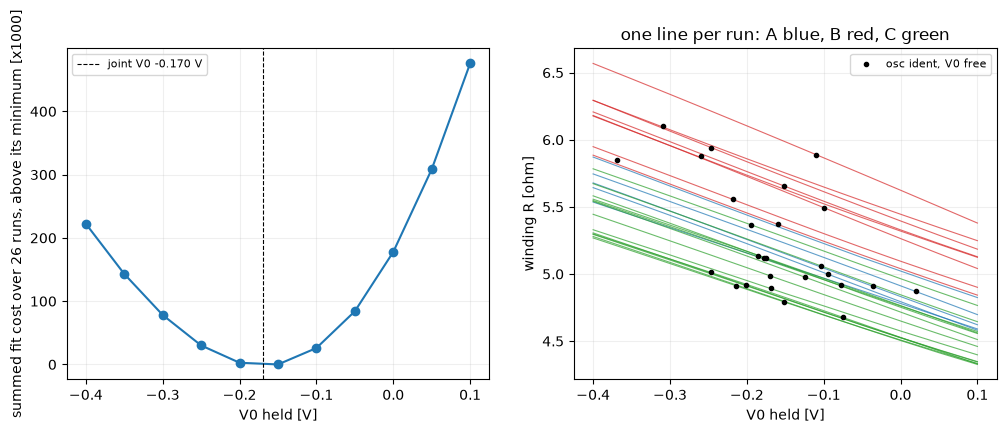

In [4]:
# Hold V0 at each value on a grid and let the rest of the fit move: R, L, the amplifier lag and
# the sample delay. All 16 from-rest captures, nothing set aside, so every run sees one recipe.
V0_GRID = np.round(np.arange(-0.40, 0.101, 0.05), 3)
rows = []
for k, run in RUN.items():
    start = [FREE[k]["fit"].p[n] for n in wf.NAMES]
    for v0 in V0_GRID:
        f = run.fit({"v0": v0}, start=start)
        rows.append({"k": k, "v0": v0, "cost": f.cost, "r": f.p["r"], "l_mh": f.p["l_mh"],
                     "vi": run.v_over_i(f.p, I_LIM)})
PROF = pd.DataFrame(rows)

# One V0 shared by every run: the minimum of the summed cost, a parabola through its three
# lowest grid points.
tot = PROF.groupby("v0").cost.sum()
i = int(np.argmin(tot.values))
x3, y3 = tot.index[i - 1:i + 2].to_numpy(), tot.values[i - 1:i + 2]
c2, c1, _ = np.polyfit(x3, y3, 2)
V0_JOINT = round(-c1 / (2 * c2), 3)
slopes = PROF.groupby("k").apply(lambda g: np.polyfit(g.v0, g.r, 1)[0], include_groups=False)
print(f"joint V0 {V0_JOINT:+.3f} V; dR/dV0 per run {slopes.median():.2f} ohm/V "
      f"(range {slopes.min():.2f} .. {slopes.max():.2f})")
own = PROF.loc[PROF.groupby("k").cost.idxmin()]
print(f"each run's own minimum on the grid: {own.v0.min():+.2f} .. {own.v0.max():+.2f} V")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
a1.plot(tot.index, (tot - tot.min()) / 1e3, "o-")
a1.axvline(V0_JOINT, color="k", lw=0.8, ls="--", label=f"joint V0 {V0_JOINT:+.3f} V")
a1.set_xlabel("V0 held [V]")
a1.set_ylabel("summed fit cost over 26 runs, above its minimum [x1000]")
a1.legend(fontsize=8)
for k, g in PROF.groupby("k"):
    ph = RUNS.phase[k]
    a2.plot(g.v0, g.r, "-", lw=0.8, color={"A": "tab:blue", "B": "tab:red", "C": "tab:green"}[ph], alpha=0.7)
a2.plot(RUNS.v0_v, RUNS.wave_r_ohm, "k.", label="osc ident, V0 free")
a2.set_xlabel("V0 held [V]")
a2.set_ylabel("winding R [ohm]")
a2.set_title("one line per run: A blue, B red, C green")
a2.legend(fontsize=8)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()

**What you are looking at.** Left, the fit cost summed over all 26 runs against the V0 held. Right, one
line per run of R against the V0 held, with `osc ident`'s free result for each run as a dot.

Every run trades the same way, about -2.07 ohm of R per volt of V0 (-1.87 to -2.38). The lines are
parallel and the free dots slide along them. That is the trade the scatter comes from.

The summed cost has a clear minimum at **V0 = -0.170 V**, so that is the one value every run gets from
here on. One run on its own puts its minimum anywhere from -0.36 to +0.02 V, which is the swing
`osc ident` printed. With 26 runs added up, the minimum is well placed.

A negative V0 is odd for a brush drop, which should push back against the drive. The fit wants it
negative in 25 of 26 runs, and `osc ident`'s own physical-bounds gate only allows down to -0.1 V. I do not
know what the negative offset stands for. It is listed under Open.

## 4. R with V0 held

Now ident's own sequence again, with V0 held at the joint value.

,anchor mean,anchor sd,anchor sd %,last nine sd
quantity,,,,
"R, V0 free (osc ident)",5.137,0.391,7.602,0.123
"V/I at the limit, V0 free",5.314,0.218,4.096,0.205
"R, V0 held at -0.170",5.232,0.123,2.347,0.128
"V/I at the limit, V0 held",5.234,0.135,2.584,0.131


anchor R against the V0 held, profile fits (nothing set aside):
v0    -0.40  -0.35  -0.30  -0.25  -0.20  -0.15  -0.10  -0.05  -0.00   0.05   0.10
mean  5.695  5.592  5.489  5.386  5.282  5.178  5.075  4.971  4.868  4.765  4.663
std   0.124  0.121  0.116  0.112  0.108  0.105  0.102  0.100  0.100  0.100  0.101

formal sd of one run's R with V0 held: 0.036 ohm (median over runs)


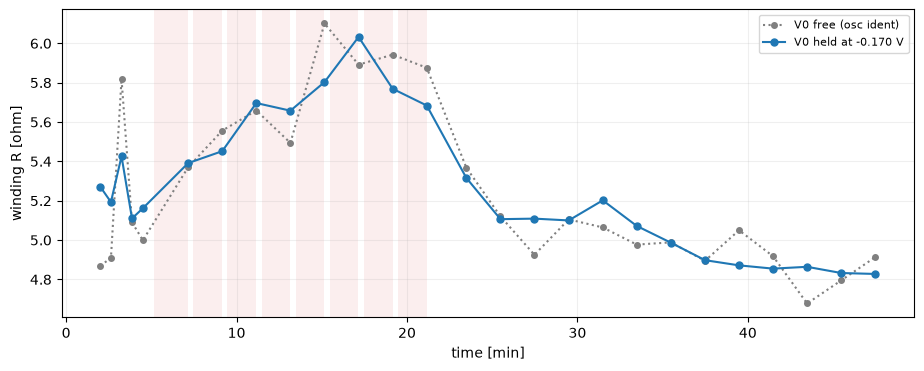

In [5]:
# osc ident's own sequence again, V0 now held at the joint value.
FIX = {}
for k, run in RUN.items():
    fit, each = run.fit_like_ident({"v0": V0_JOINT})
    keep = set(each["index"][~each.set_aside])
    FIX[k] = dict(fit=fit, each=each, vi=run.v_over_i(fit.p, I_LIM, keep))
RUNS["r_free"] = [FREE[k]["fit"].p["r"] for k in RUNS.k]
RUNS["v0_free"] = [FREE[k]["fit"].p["v0"] for k in RUNS.k]
RUNS["vi_free"] = [FREE[k]["vi"] for k in RUNS.k]
RUNS["r"] = [FIX[k]["fit"].p["r"] for k in RUNS.k]
RUNS["r_sd"] = [FIX[k]["fit"].sd["r"] for k in RUNS.k]
RUNS["vi"] = [FIX[k]["vi"] for k in RUNS.k]
RUNS["l_mh"] = [FIX[k]["fit"].p["l_mh"] for k in RUNS.k]

A = RUNS.phase == "A"
TAIL = RUNS.k >= 17                          # the last nine runs, the can within 1 C of its end
rows = []
for name, col in (("R, V0 free (osc ident)", "r_free"), ("V/I at the limit, V0 free", "vi_free"),
                  (f"R, V0 held at {V0_JOINT:+.3f}", "r"), ("V/I at the limit, V0 held", "vi")):
    rows.append({"quantity": name, "anchor mean": RUNS[col][A].mean(), "anchor sd": RUNS[col][A].std(),
                 "anchor sd %": RUNS[col][A].std() / RUNS[col][A].mean() * 100,
                 "last nine sd": RUNS[col][TAIL].std()})
display(pd.DataFrame(rows).set_index("quantity").round(3))

# Does the choice of V0 matter for the scatter, or only for the level?
s = PROF[PROF.k.isin(RUNS.k[A])].groupby("v0").r.agg(["mean", "std"])
print("anchor R against the V0 held, profile fits (nothing set aside):")
print(s.T.round(3).to_string())
print(f"\nformal sd of one run's R with V0 held: {RUNS.r_sd.median():.3f} ohm (median over runs)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(RUNS.t_s / 60, RUNS.r_free, "o:", ms=4, color="grey", label="V0 free (osc ident)")
ax.plot(RUNS.t_s / 60, RUNS.r, "o-", ms=5, label=f"V0 held at {V0_JOINT:+.3f} V")
for _, w in HEAT.iterrows():
    ax.axvspan(w.start_s / 60, w.end_s / 60, color="tab:red", alpha=0.08, lw=0)
ax.set_xlabel("time [min]")
ax.set_ylabel("winding R [ohm]")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** The table compares the cold anchor's five runs four ways: R and V/I at the
limit, with V0 free and with V0 held. The printout under it shows the anchor's R at every V0 on the grid.
The plot is R through the evening, both ways.

Holding V0 cuts the cold scatter of R from 0.39 ohm (7.6%) to 0.12 ohm (2.3%). Which V0 is held barely
matters for the scatter. Anywhere from -0.40 to +0.10 V gives 0.10 to 0.12 ohm. It only moves the
level. So the scatter came from the trade, and the value of V0 is a separate question.

0.12 ohm is still three times the 0.036 ohm the fit's own covariance claims for one run. Something
besides sample noise moves R from run to run at one temperature. The rotor stops at a different angle
each time, and the brushes sit on different commutator bars, which is my first suspect, but this data
does not test it.

The trace on the right side of the plot is the bigger problem. After cooling, R keeps falling. The
last runs sit around 4.83 ohm, well under the anchor's 5.23, while the can is only 1.6 C cooler.

## 5. R against the can

heat plateau, runs 7-12: R +10.4% over the anchor at the can +10.2 C, apparent 1.02 %/C
resting ends, anchor and runs 17-25: slope 0.200 ohm/C = 3.82 %/C, can -1.59 C, R -5.7%
copper is 0.39 %/C


k,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
phase,A,A,A,A,A,B,B,B,B,B,...,C,C,C,C,C,C,C,C,C,C
t_s,120.5,157.7,195.0,231.9,270.2,429.6,549.6,669.6,789.6,909.6,...,1769.4,1889.3,2008.9,2128.6,2249.3,2369.0,2488.8,2608.7,2728.8,2849.0
can_c,28.86,28.82,28.79,28.78,28.85,36.22,38.53,39.18,39.37,38.18,...,27.72,27.61,27.53,27.34,27.42,27.12,27.12,27.02,26.71,27.22
rail_v,8.028,7.996,7.988,8.024,7.996,8.0,7.968,7.936,7.912,7.916,...,7.855,7.875,7.867,7.879,7.847,7.871,7.843,7.859,7.839,7.843
r_free,4.87,4.909,5.819,5.09,4.999,5.37,5.556,5.658,5.494,6.101,...,5.105,5.064,4.977,4.988,4.895,5.05,4.918,4.678,4.795,4.914
v0_free,0.02,-0.036,-0.359,-0.159,-0.095,-0.16,-0.218,-0.153,-0.1,-0.308,...,-0.173,-0.105,-0.125,-0.171,-0.168,-0.262,-0.202,-0.075,-0.151,-0.215
r,5.271,5.193,5.426,5.11,5.162,5.391,5.452,5.696,5.658,5.803,...,5.1,5.202,5.072,4.987,4.898,4.872,4.855,4.864,4.833,4.828
dr_pct,0.732,-0.746,3.697,-2.337,-1.346,3.039,4.198,8.873,8.131,10.908,...,-2.529,-0.578,-3.065,-4.687,-6.391,-6.894,-7.211,-7.035,-7.637,-7.729
t_wind_cu,30.698,26.907,38.298,22.828,25.369,36.613,39.585,51.571,49.67,56.79,...,22.334,27.338,20.961,16.803,12.434,11.144,10.331,10.781,9.237,9.003


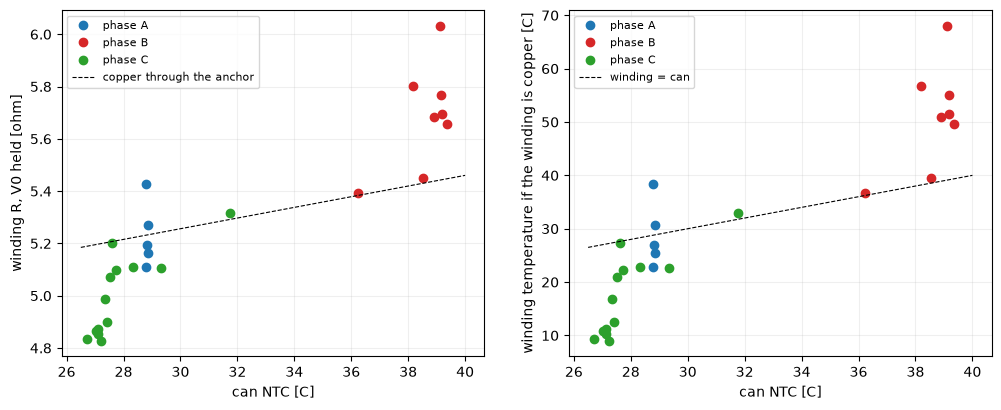

In [6]:
R_A = RUNS.r[A].mean()                       # the anchor's R, V0 held
T_A = RUNS.can_c[A].mean()                   # and its can temperature
RUNS["dr_pct"] = (RUNS.r / R_A - 1) * 100
RUNS["dcan"] = RUNS.can_c - T_A
# The winding temperature R implies if the winding is copper and the anchor's winding sat at
# the anchor's can temperature.
RUNS["t_wind_cu"] = T_A + (RUNS.r / R_A - 1) / ALPHA_CU

PLAT = RUNS.k.between(7, 12)                 # the heat phase once the can has levelled
EQ = A | TAIL                                # both ends, the motor resting
b_eq = np.polyfit(RUNS.can_c[EQ], RUNS.r[EQ], 1)[0]
print(f"heat plateau, runs 7-12: R {RUNS.dr_pct[PLAT].mean():+.1f}% over the anchor at the can "
      f"{RUNS.dcan[PLAT].mean():+.1f} C, apparent {RUNS.dr_pct[PLAT].mean() / RUNS.dcan[PLAT].mean():.2f} %/C")
print(f"resting ends, anchor and runs 17-25: slope {b_eq:.3f} ohm/C = {b_eq / R_A * 100:.2f} %/C, "
      f"can {RUNS.can_c[TAIL].mean() - T_A:+.2f} C, R {RUNS.dr_pct[TAIL].mean():+.1f}%")
print(f"copper is {ALPHA_CU * 100:.2f} %/C")
display(RUNS[["k", "phase", "t_s", "can_c", "rail_v", "r_free", "v0_free", "r", "dr_pct", "t_wind_cu"]]
        .set_index("k").round(3).T)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for ph, col in (("A", "tab:blue"), ("B", "tab:red"), ("C", "tab:green")):
    g = RUNS[RUNS.phase == ph]
    a1.plot(g.can_c, g.r, "o", color=col, label=f"phase {ph}")
    a2.plot(g.can_c, g.t_wind_cu, "o", color=col, label=f"phase {ph}")
x = np.linspace(26.5, 40, 2)
a1.plot(x, R_A * (1 + ALPHA_CU * (x - T_A)), "k--", lw=0.8, label="copper through the anchor")
a1.set_xlabel("can NTC [C]")
a1.set_ylabel(f"winding R, V0 held [ohm]")
a2.plot(x, x, "k--", lw=0.8, label="winding = can")
a2.set_xlabel("can NTC [C]")
a2.set_ylabel("winding temperature if the winding is copper [C]")
for ax in (a1, a2):
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
plt.show()

**What you are looking at.** Left, R (V0 held) against the can, with the copper line drawn through the
anchor. Right, the winding temperature R implies if the winding is copper and sat at the can's
temperature during the anchor.

Two different slopes show up, and neither is copper:

- **During the heat** (runs 7-12) R is 10.4% over the anchor with the can 10.2 C warmer, an apparent
  1.02 %/C. The heat flows from the winding to the can, so the winding is the hotter of the two. That
  makes 1.02 %/C an upper bound on the winding's coefficient. With copper's 0.39 %/C the winding would
  be about 26 C over the anchor at the moment of the capture, against 10 C on the can.
- **At rest, both ends** (the anchor and runs 17-25) R falls 3.8 %/C, ten times copper. R ended 5.7%
  under the anchor for a can 1.6 C cooler, where copper predicts 0.6%. Read through copper, the last
  runs put the winding at 9 to 12 C, in a room around 26 C. That is impossible, so about -5% of R
  moved for a reason that is not the winding's temperature.

So R is not a usable absolute thermometer from this run. A drift of -5% is about -13 C of copper. The
coefficient cannot be read here either. The resting points have the drift, the heating points have
the winding running hotter than the can, and the thermal model in the next section cannot separate
the coefficient from the winding-to-can resistance (it tries, and runs to its bound).

**Read against the overnight rest series (section 11), the -5% is not a drift.** The anchor assumes a
winding at the can's temperature, and it was not. Against the night's R at rest the anchor reads 14 to
31 C over its can, and the last runs of the cool land within 2 C of theirs.

## 6. Thermal model

Here is the idea. Think of the motor as a small pot of water on a stove. The heat goes in through the
winding, and leaks out to the air. A **thermal resistance** $R_{th}$ (C per watt) says how many degrees
over the room one watt holds it at, once it settles. A **heat capacity** $C$ (joules per C) says how much
heat it takes to warm it one degree. Their product is the **time constant** $\tau = C R_{th}$ in seconds,
how long it takes to get about 63% of the way to where it is going.

One node, everything at one temperature $T$, with the room at $T_a$:

$$C \frac{dT}{dt} = I^2 R(T) - \frac{T - T_a}{R_{th}}$$

Two nodes, the winding $T_w$ feeding the can $T_c$, the can feeding the air:

$$C_w \frac{dT_w}{dt} = I^2 R(T_w) - \frac{T_w - T_c}{R_{wc}}, \qquad
C_c \frac{dT_c}{dt} = \frac{T_w - T_c}{R_{wc}} - \frac{T_c - T_a}{R_{ca}}$$

$R(T) = R_0 (1 + \alpha (T - T_{a0}))$ with $\alpha$, the temperature coefficient, held at copper's
0.0039 per C. The current is the heater's rms from section 1, on only inside the heat windows.

The room was not steady. The anchor's can sat at 28.9 C and the last runs at 26.7 to 27.2 C, so the
ambient falls on a straight line, $T_a = T_{a0} + b t$, fitted with everything else. Each run's R sits
at its start plus 9 s, the middle of its 16 from-rest captures. The run logs only its start, so that
9 s is an estimate, and the sensitivity table below moves it to 5 and 13 s.

The fits weigh the can at 0.1 C and R at 0.1 ohm, the anchor's scatter. The R-only fit cannot place
the room on its own (a falling room and a falling R look the same to it), so it takes the ambient
line the can gave the two-node fit.

In [7]:
# The heater's power is I^2 R with the R that moves with the winding temperature. The heater
# windows come from heater.csv, one rms current each. The bursts themselves heat nothing worth
# counting: 16 captures of half a millisecond.
T0, DT = 120.0, 0.5                          # model start (the first anchor run) and step, s
TG = np.arange(T0, RUNS.t_s.max() + 40, DT)
I2 = np.zeros_like(TG)
for _, w in HEAT.iterrows():
    I2[(TG >= w.start_s) & (TG < w.end_s)] = w.i_rms_A ** 2
CAP_LAG = 9.0                                # s from a run's start to the middle of its 16 from-rest captures


def sim(cw, cc, rwc, rca, ta0, tb, r0, alpha=ALPHA_CU, two=True):
    # Euler at 0.5 s. Ambient falls on a line, ta0 + tb t. Both nodes start at ta0.
    tw = tc = ta0
    Tw, Tc = np.empty_like(TG), np.empty_like(TG)
    for n, t in enumerate(TG):
        ta = ta0 + tb * (t - T0)
        p = I2[n] * r0 * (1 + alpha * (tw - ta0))          # R at the winding's own temperature
        if two:
            q = (tw - tc) / rwc                            # winding -> can
            tw += DT * (p - q) / cw
            tc += DT * (q - (tc - ta) / rca) / cc          # can -> air
        else:
            tw += DT * (p - (tw - ta) / rca) / cc          # one node: it is the can and the winding
            tc = tw
        Tw[n], Tc[n] = tw, tc
    return Tw, Tc


SIG_C, SIG_R = 0.1, 0.1                     # can noise C, one run's R noise ohm (the anchor's sd)
NAMES2 = ["cw", "cc", "rwc", "rca", "ta0", "tb", "r0"]
Q0 = dict(cw=0.6, cc=8.5, rwc=30, rca=12, ta0=28.9, tb=-0.0008, r0=5.2, alpha=ALPHA_CU, drift=0)
LO = dict(cw=0.02, cc=0.5, rwc=0.5, rca=1, ta0=20, tb=-0.01, r0=3, alpha=0.0005, drift=-2)
HI = dict(cw=50, cc=200, rwc=300, rca=100, ta0=40, tb=0.01, r0=8, alpha=0.05, drift=2)


def fit_thermal(keep=None, lag=CAP_LAG, extra=(), use_can=True, use_r=True, two=True, fix=None):
    """Least squares on the can (before and after every run) and on R (once per run).
    extra: 'alpha' frees the coefficient, 'drift' adds R drift in ohm per 1000 s.
    fix: parameters held at the values given (R alone cannot place the ambient)."""
    fix = fix or {}
    rr = RUNS if keep is None else RUNS[RUNS.k.isin(keep)]
    ct = np.r_[rr.t_s, rr.t_s + rr.burst_s]
    cy = np.r_[rr.can_before, rr.can_after]
    rt, ry = rr.t_s.to_numpy() + lag, rr.r.to_numpy()
    names = [n for n in (NAMES2 if two else ["cc", "rca", "ta0", "tb", "r0"]) if n not in fix] + list(extra)

    def res(q):
        p = dict(Q0, **fix, **dict(zip(names, q)))
        Tw, Tc = sim(p["cw"], p["cc"], p["rwc"], p["rca"], p["ta0"], p["tb"], p["r0"], p["alpha"], two)
        out = []
        if use_can:
            out.append((np.interp(ct, TG, Tc) - cy) / SIG_C)
        if use_r:
            rm = p["r0"] * (1 + p["alpha"] * (np.interp(rt, TG, Tw) - p["ta0"])) + p["drift"] * (rt - T0) / 1e3
            out.append((rm - ry) / SIG_R)
        return np.concatenate(out)

    s = least_squares(res, [Q0[n] for n in names], bounds=([LO[n] for n in names], [HI[n] for n in names]),
                      x_scale="jac")
    cov = np.linalg.pinv(s.jac.T @ s.jac) * (s.fun @ s.fun) / max(len(s.fun) - len(s.x), 1)
    p = dict(Q0, **fix, **dict(zip(names, s.x)))
    sd = dict(zip(names, np.sqrt(np.clip(np.diag(cov), 0, None))))
    if not two:
        p["cw"], p["rwc"] = np.nan, 0.0
    p.update(tau_w=p["cw"] * p["rwc"], tau_c=p["cc"] * p["rca"], rth=p["rwc"] + p["rca"])
    nc = len(ct) if use_can else 0
    p["rms_can"] = np.sqrt(np.mean((s.fun[:nc] * SIG_C) ** 2)) if use_can else np.nan
    p["rms_r"] = np.sqrt(np.mean((s.fun[nc:] * SIG_R) ** 2)) if use_r else np.nan
    # tau and R_th errors by first-order propagation through the covariance
    def prop(f):
        g = np.zeros(len(names))
        for j, n in enumerate(names):
            h = 1e-6 * max(abs(p[n]), 1e-6)
            q = dict(p); q[n] += h
            g[j] = (f(q) - f(p)) / h
        return float(np.sqrt(max(g @ cov @ g, 0.0)))
    sd["tau_c"] = prop(lambda q: q["cc"] * q["rca"])
    if two:
        sd["tau_w"] = prop(lambda q: q["cw"] * q["rwc"])
        sd["rth"] = prop(lambda q: q["rwc"] + q["rca"])
    else:
        sd["rth"] = sd["rca"]
    return p, sd


def show(fits):
    cols = ["cw", "rwc", "tau_w", "cc", "rca", "tau_c", "rth", "ta0", "tb", "r0", "alpha", "drift", "rms_can", "rms_r"]
    rows = {}
    for name, (p, sd) in fits.items():
        rows[name] = {c: (f"{p[c]:.4g}" + (f" +/- {sd[c]:.2g}" if c in sd else "")) for c in cols}
    display(pd.DataFrame(rows).T)

,cw,rwc,tau_w,cc,rca,tau_c,rth,ta0,tb,r0,alpha,drift,rms_can,rms_r
"one node, can only",nan,0,nan,9.77 +/- 0.27,13.43 +/- 0.17,131.2 +/- 5.3,13.43 +/- 0.17,28.91 +/- 0.12,-0.0008042 +/- 7.4e-05,5.338 +/- 0.079,0.0039,0,0.3931,nan
"one node, R only",nan,0,nan,4.023 +/- 0.94,45.02 +/- 5,181.1 +/- 48,45.02 +/- 5,28.9,-0.0007695,5.047 +/- 0.039,0.0039,0,nan,0.1425
"two nodes, can + R",0.5639 +/- 0.26,33.5 +/- 9.1,18.89 +/- 5,8.535 +/- 0.88,12.17 +/- 0.33,103.8 +/- 8.7,45.67 +/- 8.8,28.9 +/- 0.071,-0.0007695 +/- 4.3e-05,5.082 +/- 0.057,0.0039,0,0.2554,0.1617


units: C in J/C, R in C/W, tau in s, ta0 in C, tb in C/s, r0 in ohm, drift in ohm per 1000 s
two nodes: winding at the heater's stop 69.0 .. 73.9 C, can there 39.2 C; at the capture, 9 s later, the winding 59.8 C
ambient 28.90 C at the first run falling -0.046 C/min, 26.80 C at the last


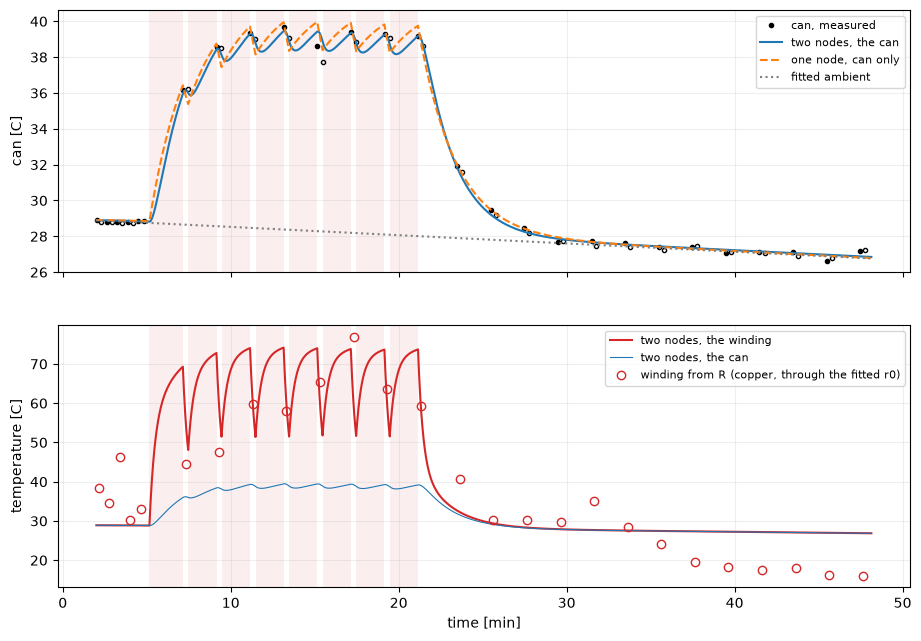

In [8]:
FITS = {"two nodes, can + R": fit_thermal()}
# R alone cannot tell a falling room from a falling R, so the R-only fits take the ambient line
# the can gave the two-node fit.
AMB = {"ta0": FITS["two nodes, can + R"][0]["ta0"], "tb": FITS["two nodes, can + R"][0]["tb"]}
FITS["one node, can only"] = fit_thermal(use_r=False, two=False)
FITS["one node, R only"] = fit_thermal(use_can=False, two=False, fix=AMB)
FITS = {k: FITS[k] for k in ("one node, can only", "one node, R only", "two nodes, can + R")}
show(FITS)
print("units: C in J/C, R in C/W, tau in s, ta0 in C, tb in C/s, r0 in ohm, drift in ohm per 1000 s")
p2 = FITS["two nodes, can + R"][0]
Tw, Tc = sim(*[p2[n] for n in NAMES2])
amb = p2["ta0"] + p2["tb"] * (TG - T0)
pk = [np.interp(w.end_s, TG, Tw) for _, w in HEAT.iterrows()]
print(f"two nodes: winding at the heater's stop {min(pk):.1f} .. {max(pk):.1f} C, can there "
      f"{np.interp(HEAT.end_s.iloc[-1], TG, Tc):.1f} C; at the capture, {CAP_LAG:.0f} s later, the winding "
      f"{np.interp(HEAT.end_s.iloc[-1] + CAP_LAG + 0.4, TG, Tw):.1f} C")
print(f"ambient {p2['ta0']:.2f} C at the first run falling {p2['tb'] * 60:.3f} C/min, "
      f"{p2['ta0'] + p2['tb'] * (RUNS.t_s.max() - T0):.2f} C at the last")

p1 = FITS["one node, can only"][0]
_, Tc1 = sim(np.nan, p1["cc"], 0, p1["rca"], p1["ta0"], p1["tb"], p1["r0"], two=False)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for _, w in HEAT.iterrows():
    for ax in (a1, a2):
        ax.axvspan(w.start_s / 60, w.end_s / 60, color="tab:red", alpha=0.08, lw=0)
a1.plot(RUNS.t_s / 60, RUNS.can_before, "ko", ms=3, label="can, measured")
a1.plot((RUNS.t_s + RUNS.burst_s) / 60, RUNS.can_after, "ko", ms=3, mfc="none")
a1.plot(TG / 60, Tc, "-", label="two nodes, the can")
a1.plot(TG / 60, Tc1, "--", label="one node, can only")
a1.plot(TG / 60, amb, ":", color="grey", label="fitted ambient")
a1.set_ylabel("can [C]")
a1.legend(fontsize=8)
a2.plot(TG / 60, Tw, "-", color="tab:red", label="two nodes, the winding")
a2.plot(TG / 60, Tc, "-", lw=0.8, label="two nodes, the can")
a2.plot((RUNS.t_s + CAP_LAG) / 60, p2["ta0"] + (RUNS.r / p2["r0"] - 1) / ALPHA_CU, "o", color="tab:red",
        mfc="none", label="winding from R (copper, through the fitted r0)")
a2.set_ylabel("temperature [C]")
a2.set_xlabel("time [min]")
a2.legend(fontsize=8)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()

**What you are looking at.** The table: every fitted parameter with its standard error. The plot, top:
the can measured, the two-node and the one-node can models, and the fitted ambient. Bottom: the
two-node winding and can, with the winding temperature each run's R implies through copper.

**One node on the can** gives 13.4 C/W and 131 s, but misses by 0.39 C rms in a pattern. It cannot
climb 7 C in two minutes and also drop half a degree in the 18 s of a burst run.

**Two nodes** fit the can to 0.26 C rms (0.15 without run 9). The two time constants come out far
apart, 19 +/- 5 s for the winding and 104 +/- 9 s for the can. That fast winding node is what drops the
can during a burst. The winding stops feeding it heat right away. Can to air is 12.2 +/- 0.3 C/W, and
that number holds through every variation below. Winding to can is 34 +/- 9 C/W, and that one leans
on copper and on the capture timing.

With copper assumed, the winding reaches 69 to 74 C at the end of each heat window, with the can at 39
C. It has already dropped to about 60 C by the time the burst captures run, 9 s later. So the
capture timing matters for the winding numbers, because the winding cools that fast.

The fitted ambient starts at 28.9 C and falls 0.046 C per minute, 26.8 C by the last run. It fits the
can, but nothing measured the room, so it is the can's ambient and not a room reading.

R is left with 0.16 ohm rms against the model, more than the 0.12 ohm cold scatter. Most of that is the
drift from section 5. The model has no way to make R fall while the can holds still.

**Section 12 refits this with R read against the night (section 11).** The can numbers hold. The
winding does not follow this 19 s node. It stays above the can for many minutes after the heat, and no
two-node fit describes both.

In [9]:
SENS = {
    "two nodes (as above)": FITS["two nodes, can + R"],
    "capture lag 5 s": fit_thermal(lag=5.0),
    "capture lag 13 s": fit_thermal(lag=13.0),
    "without run 9": fit_thermal(keep=[k for k in RUNS.k if k != 9]),
    "R drift term": fit_thermal(extra=("drift",)),
    "alpha free": fit_thermal(extra=("alpha",)),
}
show(SENS)

# R left over once the model has taken the temperature out, against the rail and against time.
p = FITS["two nodes, can + R"][0]
Tw, _ = sim(*[p[n] for n in NAMES2])
RUNS["r_left"] = RUNS.r - p["r0"] * (1 + ALPHA_CU * (np.interp(RUNS.t_s + CAP_LAG, TG, Tw) - p["ta0"]))
for col in ("rail_v", "t_s", "v0_free"):
    print(f"R left over against {col:>8}: r = {np.corrcoef(RUNS[col], RUNS.r_left)[0, 1]:+.2f}, "
          f"slope {np.polyfit(RUNS[col], RUNS.r_left, 1)[0]:+.4g} ohm per unit")
print(f"rail against time: r = {np.corrcoef(RUNS.rail_v, RUNS.t_s)[0, 1]:+.2f}")

,cw,rwc,tau_w,cc,rca,tau_c,rth,ta0,tb,r0,alpha,drift,rms_can,rms_r
two nodes (as above),0.5639 +/- 0.26,33.5 +/- 9.1,18.89 +/- 5,8.535 +/- 0.88,12.17 +/- 0.33,103.8 +/- 8.7,45.67 +/- 8.8,28.9 +/- 0.071,-0.0007695 +/- 4.3e-05,5.082 +/- 0.057,0.0039,0,0.2554,0.1617
capture lag 5 s,0.7078 +/- 0.31,27.58 +/- 7,19.52 +/- 5.3,8.158 +/- 0.85,12.42 +/- 0.26,101.3 +/- 9.5,40 +/- 6.8,28.9 +/- 0.071,-0.0007694 +/- 4.3e-05,5.081 +/- 0.057,0.0039,0,0.2554,0.1612
capture lag 13 s,0.446 +/- 0.22,41.06 +/- 12,18.31 +/- 4.7,8.945 +/- 0.95,11.84 +/- 0.46,106 +/- 8.1,52.9 +/- 12,28.9 +/- 0.072,-0.0007697 +/- 4.3e-05,5.082 +/- 0.057,0.0039,0,0.2554,0.1621
without run 9,0.6553 +/- 0.22,31.21 +/- 6.1,20.45 +/- 4,8.239 +/- 0.67,12.47 +/- 0.23,102.7 +/- 7,43.68 +/- 5.9,28.89 +/- 0.048,-0.0007696 +/- 2.9e-05,5.081 +/- 0.038,0.0039,0,0.1485,0.1628
R drift term,0.804 +/- 0.46,24.65 +/- 9.4,19.82 +/- 5.7,8.27 +/- 1.1,12.1 +/- 0.31,100.1 +/- 11,36.75 +/- 9.2,28.89 +/- 0.07,-0.0007682 +/- 4.2e-05,5.252 +/- 0.1,0.0039,-0.1154 +/- 0.057,0.2554,0.1321
alpha free,0.0599 +/- 0.014,300 +/- 0.00031,17.97 +/- 4.1,9.438 +/- 0.61,11.96 +/- 0.34,112.9 +/- 5.2,312 +/- 0.34,28.88 +/- 0.071,-0.0007634 +/- 4.3e-05,5.07 +/- 0.056,0.0006179 +/- 0.00011,0,0.2458,0.177


R left over against   rail_v: r = +0.36, slope +0.9543 ohm per unit
R left over against      t_s: r = -0.53, slope -9.773e-05 ohm per unit
R left over against  v0_free: r = +0.05, slope +0.104 ohm per unit
rail against time: r = -0.91


**What you are looking at.** The two-node fit again with one thing changed per row, then what is left
of R once the model has taken the temperature out.

- **Capture timing** (5 or 13 s instead of 9) moves winding to can from 28 to 41 C/W and the total from
  40 to 53. Can to air and the can's time constant barely move.
- **Without run 9** the can fits to 0.15 C rms and nothing else moves past its error bar.
- **An R drift term** comes out at -0.115 +/- 0.057 ohm per 1000 s, two standard errors. It brings R's
  leftover down to 0.13 ohm, near the cold scatter.
- **The coefficient free** runs winding to can to its 300 C/W bound and the coefficient down to 0.06
  %/C. A very hot winding with a small coefficient and a mild winding with copper's coefficient change
  R the same way, and the can cannot tell them apart. So $\alpha$ is not determined by this data.

R's leftover correlates with the rail (+0.36) and with time (-0.53), but the rail and time are
themselves at -0.91 here, since the pack sagged slowly all evening. This run cannot separate them.

heat test: 180 s at |i| mean 0.246 A, can 29.97 -> 34.29 C, 29.15 C after 280 s of cooling
two-node prediction from this run's fit: 32.88 C at the end of the heat, 30.18 C at the end; rms against the log 0.78 C
one exponential through the cooling log alone: tau 151 s toward 28.18 C


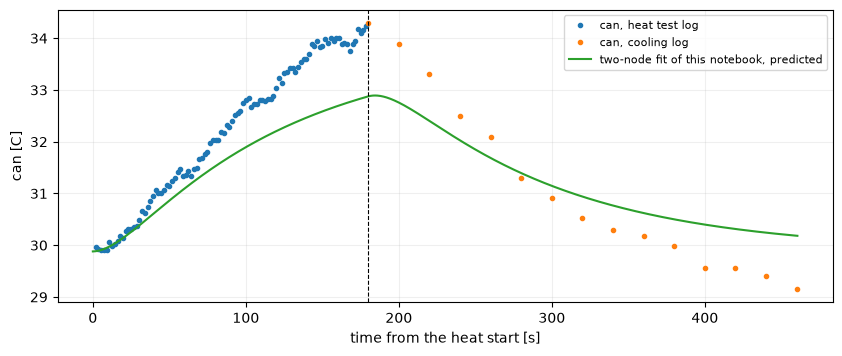

In [10]:
# An earlier, separate dither: about 3 minutes at a lower current, the can logged every ~1.8 s,
# then 280 s of cooling with torque off. Nothing from it went into the fits above.
import re
txt = (DS / "heattest.log").read_text()
heat = [(float(a), float(b), float(c)) for a, b, c in
        re.findall(r"^\s*([\d.]+)s pos \d+ ntc ([\d.]+) C \|i\| mean (\d+)", txt, re.M)]
cool = [(float(a), float(b)) for a, b in re.findall(r"^cool\s+(\d+)s ntc ([\d.]+) C", txt, re.M)]
t_end = float(re.search(r"heat done (\d+)s", txt).group(1))
ht = np.array([h[0] for h in heat]); hc = np.array([h[1] for h in heat])
i_mean = heat[-1][2] * board.a_per_count     # the log's running mean of |i|, not an rms
ct = np.array([t_end + c[0] for c in cool]); cc_ = np.array([c[1] for c in cool])
ta = float(re.search(r"ntc start ([\d.]+) C", txt).group(1))

p = FITS["two nodes, can + R"][0]
t = np.arange(0, ct.max() + 1, DT)
tw = tc = 0.0
pred = np.empty_like(t)
for n, tt in enumerate(t):
    pw = (tt < t_end) * i_mean ** 2 * p["r0"] * (1 + ALPHA_CU * tw)
    q = (tw - tc) / p["rwc"]
    tw += DT * (pw - q) / p["cw"]
    tc += DT * (q - tc / p["rca"]) / p["cc"]
    pred[n] = ta + tc
print(f"heat test: {t_end:.0f} s at |i| mean {i_mean:.3f} A, can {hc[0]:.2f} -> {cc_[0]:.2f} C, "
      f"{cc_[-1]:.2f} C after {ct[-1] - t_end:.0f} s of cooling")
print(f"two-node prediction from this run's fit: {np.interp(t_end, t, pred):.2f} C at the end of the heat, "
      f"{np.interp(ct[-1], t, pred):.2f} C at the end; rms against the log {np.sqrt(np.mean((np.interp(np.r_[ht, ct], t, pred) - np.r_[hc, cc_]) ** 2)):.2f} C")
# the cooling log on its own: one exponential toward a free floor
s = least_squares(lambda q: q[0] + q[1] * np.exp(-(ct - t_end) / q[2]) - cc_, [ta, cc_[0] - ta, 100])
print(f"one exponential through the cooling log alone: tau {s.x[2]:.0f} s toward {s.x[0]:.2f} C")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(ht, hc, ".", label="can, heat test log")
ax.plot(ct, cc_, ".", label="can, cooling log")
ax.plot(t, pred, "-", label="two-node fit of this notebook, predicted")
ax.axvline(t_end, color="k", lw=0.8, ls="--")
ax.set_xlabel("time from the heat start [s]")
ax.set_ylabel("can [C]")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** An earlier, separate test that went into no fit. About 3 minutes of
dither at a lower current, the can logged every 1.8 s, then 280 s of cooling. The line is what this
notebook's two-node fit predicts for it.

It does not agree well. The model ends the heat at 32.9 C against a measured 34.3 C, so it under-heats
by about a third. The cooling log on its own decays with a 151 s time constant, against the model's
slow mode of about 110 s. The log gives only the running mean of $|i|$, not its rms, and nothing says
the can was settled when it started (29.9 C, with the room around 26). Either could account for part
of it. I count this as an open discrepancy, not as a check that passed.

## 7. Stage length

How short could an ident stage be? First, cutting this run short and fitting what is left, then a
simulation of a stage the servo could run on itself.

In [11]:
# Cut this run short and fit what is left: the anchor plus the first n heat runs, or the anchor,
# the whole heat phase and the first m cooling runs.
CUTS = {}
for n in (2, 4, 6, 8):
    CUTS[f"anchor + {n} heat runs ({n * 2} min of heat)"] = list(range(5)) + list(range(5, 5 + n))
for m in (2, 4, 7, 13):
    CUTS[f"anchor + 8 heat + {m} cool runs"] = list(range(13 + m))
rows = []
for name, keep in CUTS.items():
    for label, kw in (("two nodes, can + R", {}), ("one node, R only", dict(use_can=False, two=False, fix=AMB))):
        p, sd = fit_thermal(keep=keep, **kw)
        r = {"cut": name, "model": label}
        for c in ("rth", "tau_c", "rca", "tau_w"):
            if c in sd:
                r[c] = p[c]
                r[c + " sd %"] = sd[c] / abs(p[c]) * 100
        rows.append(r)
SUB = pd.DataFrame(rows).set_index(["cut", "model"])
display(SUB.round(1))

rth  rth sd %  \
cut                                   model                                 
anchor + 2 heat runs (4 min of heat)  two nodes, can + R   24.9      35.0   
                                      one node, R only     16.7     181.6   
anchor + 4 heat runs (8 min of heat)  two nodes, can + R   28.0      13.4   
                                      one node, R only     53.0     177.4   
anchor + 6 heat runs (12 min of heat) two nodes, can + R   32.1      28.3   
                                      one node, R only    100.0     142.0   
anchor + 8 heat runs (16 min of heat) two nodes, can + R   33.7      24.7   
                                      one node, R only     38.5      22.4   
anchor + 8 heat + 2 cool runs         two nodes, can + R   33.5      33.7   
                                      one node, R only     34.5      16.4   
anchor + 8 heat + 4 cool runs         two nodes, can + R   34.8      30.4   
                                      one node, R only     35.6      14.4   
anchor + 8 heat + 7 cool runs         two nodes, can + R   37.3      25.7   
                                      one node, R only     36.8      12.3   
anchor + 8 heat + 13 cool runs        two nodes, can + R   45.7      19.2   
                                      one node, R only     45.0      11.0   

                                                           tau_c  tau_c sd %  \
cut                                   model                                    
anchor + 2 heat runs (4 min of heat)  two nodes, can + R    67.0       616.9   
                                      one node, R only     153.2       397.6   
anchor + 4 heat runs (8 min of heat)  two nodes, can + R    63.5       214.8   
                                      one node, R only     667.9       246.6   
anchor + 6 heat runs (12 min of heat) two nodes, can + R    56.6       145.9   
                                      one node, R only    1346.3       180.8   
anchor + 8 heat runs (16 min of heat) two nodes, can + R    56.9       208.9   
                                      one node, R only     353.5        59.5   
anchor + 8 heat + 2 cool runs         two nodes, can + R    66.4       123.6   
                                      one node, R only     161.7        35.9   
anchor + 8 heat + 4 cool runs         two nodes, can + R    92.0        21.6   
                                      one node, R only     152.7        32.6   
anchor + 8 heat + 7 cool runs         two nodes, can + R   100.0        12.6   
                                      one node, R only     156.2        29.6   
anchor + 8 heat + 13 cool runs        two nodes, can + R   103.8         8.4   
                                      one node, R only     181.1        26.4   

                                                            rca  rca sd %  \
cut                                   model                                 
anchor + 2 heat runs (4 min of heat)  two nodes, can + R   12.9       5.6   
                                      one node, R only     16.7     181.6   
anchor + 4 heat runs (8 min of heat)  two nodes, can + R   12.6       4.1   
                                      one node, R only     53.0     177.4   
anchor + 6 heat runs (12 min of heat) two nodes, can + R   12.8       6.3   
                                      one node, R only    100.0     142.0   
anchor + 8 heat runs (16 min of heat) two nodes, can + R   12.0       4.9   
                                      one node, R only     38.5      22.4   
anchor + 8 heat + 2 cool runs         two nodes, can + R   11.8       3.2   
                                      one node, R only     34.5      16.4   
anchor + 8 heat + 4 cool runs         two nodes, can + R   12.2       2.9   
                                      one node, R only     35.6      14.4   
anchor + 8 heat + 7 cool runs         two nodes, can + R   12.3       2.8   
                                      one node, R only     36.8      12.3   


**What you are looking at.** Each cut keeps the anchor plus the first runs of the heat, or plus the
whole heat and the first runs of the cooling. The sd columns are the fit's own standard errors, in
percent.

With the can NTC (two nodes), can to air settles to about 5% after only two heat runs, 4 minutes of
heat. The can's time constant does not settle until the cooling is in. Heating alone leaves it at
57 to 67 s with error bars over 100%. Seven cooling runs (14 minutes) bring it to 100 s +/- 13%, the
whole cooling phase to 104 s +/- 8%. The total R_th, which goes through the winding, never gets better
than 19%.

From R alone (one node), nothing is pinned during the heat. With all of the heat and the cooling,
R_th lands at 45 C/W +/- 11%, close to the two-node total, but its time constant sits at 150 to 180 s
with 26-36% errors. The drift from section 5 pulls on this fit. It pins the room-temperature R low,
so the cooling runs look warm for longer, and the time constant comes out long.

one node on noise-free R, 30 min heat + 30 min cool: R_th 43.7 C/W, tau 55 s (the two-node truth: R_th 45.7, taus 19 and 104 s)


,burst every s,stage min,R reads,R_th median,R_th spread %,tau median s,tau spread %
0,120,4,2,42.1,55.6,30.0,35.1
1,120,8,4,47.0,29.7,36.3,96.7
2,120,12,6,44.5,20.0,40.1,75.8
3,120,16,8,44.8,16.3,46.7,63.0
4,120,24,12,45.1,14.8,53.2,57.3
5,120,32,16,45.0,12.9,58.9,53.0
6,60,4,4,53.8,54.5,31.3,98.0
7,60,8,8,42.4,24.7,39.4,56.5
8,60,12,12,41.3,16.4,41.3,42.2
9,60,16,16,44.2,14.7,44.5,40.1


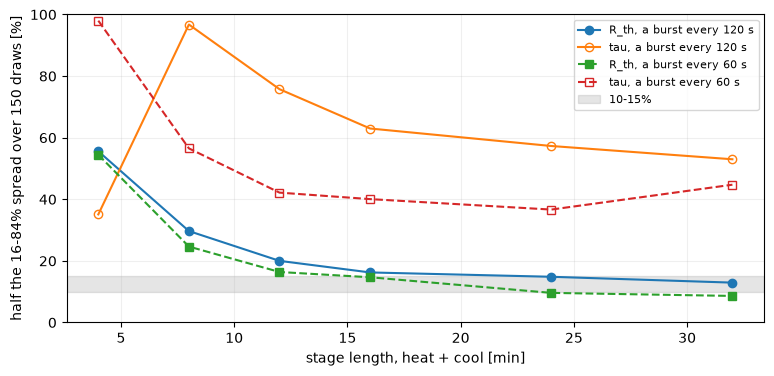

In [12]:
# A stage the servo could run on itself, with no can NTC: heat at this run's current, read R with
# an ident burst every `every` s (the heat pauses 18 s for each, as here), then cool for as long
# as it heated, reading R at the same pace. The truth is the two-node fit above with a steady
# ambient; R carries the anchor's 0.10 ohm noise. Each draw fits one node to R alone.
TRUTH = FITS["two nodes, can + R"][0]
I2_HEAT = HEAT.i_rms_A.mean() ** 2
BURST_S, DTM = 18.0, 0.5


def stage(heat_s, every):
    t = np.arange(0, 2 * heat_s + every, DTM)
    on = np.zeros_like(t)
    reads = []
    c = 0.0
    while c < 2 * heat_s:
        if c < heat_s:
            on[(t >= c) & (t < c + every - BURST_S)] = 1          # heat, then a burst
            c += every - BURST_S
        reads.append(c + CAP_LAG)
        c += BURST_S if c < heat_s else every
    return t, on, np.array(reads)


def truth_r(t, on, reads):
    p = TRUTH
    tw = tc = 0.0
    out = np.empty_like(t)
    for n in range(len(t)):
        pw = on[n] * I2_HEAT * p["r0"] * (1 + ALPHA_CU * tw)
        q = (tw - tc) / p["rwc"]
        tw += DTM * (pw - q) / p["cw"]
        tc += DTM * (q - tc / p["rca"]) / p["cc"]
        out[n] = tw
    return p["r0"] * (1 + ALPHA_CU * np.interp(reads, t, out))


def one_node(t, on, reads, r_obs):
    # T rise above ambient, one node, the power at the ambient R: a first-order filter of on(t).
    def model(q):
        c, rth, r0 = q
        a = np.exp(-DTM / (c * rth))
        rise = lfilter([0, (1 - a) * rth * I2_HEAT * r0], [1, -a], on)
        return r0 * (1 + ALPHA_CU * np.interp(reads, t, rise))
    s = least_squares(lambda q: model(q) - r_obs, [5, 30, r_obs[0]],
                      bounds=([0.05, 1, 3], [500, 500, 8]), x_scale="jac")
    c, rth, r0 = s.x
    return rth, c * rth


rng = np.random.default_rng(14)
REF = one_node(*stage(1800, 120), truth_r(*stage(1800, 120)))
print(f"one node on noise-free R, 30 min heat + 30 min cool: R_th {REF[0]:.1f} C/W, tau {REF[1]:.0f} s "
      f"(the two-node truth: R_th {TRUTH['rth']:.1f}, taus {TRUTH['tau_w']:.0f} and {TRUTH['tau_c']:.0f} s)")
rows = []
for every in (120, 60):
    for heat_min in (2, 4, 6, 8, 12, 16):
        t, on, reads = stage(heat_min * 60, every)
        r_true = truth_r(t, on, reads)
        draws = np.array([one_node(t, on, reads, r_true + rng.normal(0, SIG_R, len(reads))) for _ in range(150)])
        rth, tau = draws[:, 0], draws[:, 1]
        rows.append({"burst every s": every, "stage min": 2 * heat_min, "R reads": len(reads),
                     "R_th median": np.median(rth), "R_th spread %": 50 * (np.percentile(rth, 84) - np.percentile(rth, 16)) / np.median(rth),
                     "tau median s": np.median(tau), "tau spread %": 50 * (np.percentile(tau, 84) - np.percentile(tau, 16)) / np.median(tau)})
MC = pd.DataFrame(rows)
display(MC.round(1))

fig, ax = plt.subplots(figsize=(9, 4))
for every, mk in ((120, "o-"), (60, "s--")):
    g = MC[MC["burst every s"] == every]
    ax.plot(g["stage min"], g["R_th spread %"], mk, label=f"R_th, a burst every {every} s")
    ax.plot(g["stage min"], g["tau spread %"], mk, mfc="none", label=f"tau, a burst every {every} s")
ax.axhspan(10, 15, color="grey", alpha=0.2, label="10-15%")
ax.set_xlabel("stage length, heat + cool [min]")
ax.set_ylabel("half the 16-84% spread over 150 draws [%]")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** A simulated stage with no can NTC. It heats at this run's current with a
burst every 120 s or every 60 s (the heat pausing 18 s for each, as here), then cools for as long as
it heated, still bursting. The truth is the two-node fit with a steady room, and every R gets the
anchor's 0.10 ohm of noise. Each of 150 draws fits one node to R alone. The spread is half the
16-84% range, about one standard deviation.

- **R_th** gets to 15% at about 24 minutes with a burst every 120 s, or 16 minutes with one every 60 s.
  It gets to 10% at about 24 minutes with a burst every 60 s. From 8 minutes on, its median sits
  within 10% of the truth's 45.7 C/W.
- **The time constant** never gets under about 35%, and its median keeps climbing with the stage
  length, 30 s for the shortest stage to 59 s for the longest. A single node is fitting two time
  constants, 19 and 104 s, and the one it reports depends on how much of each the stage saw. Pinning
  tau to 10-15% needs a two-node model, and from R alone that needs much more than this.

The simulation has no drift in it. On the real data the drift alone moved R by more than the
whole noise budget, so these are best-case lengths.

**The truth model here is section 6's fit, which section 12 finds does not describe R**, and the
noise is the evening's 0.10 ohm where R at rest repeats to 0.033 (section 10). These lengths need
redoing once a model fits both the can and R.

## 8. V/I at the limit

`osc ident` plans its stall-safe duties from V/I at the current limit: duty times rail over current,
read off the burst's line at 0.253 A. Does it move with temperature the way R does, with the rail, or
with V0?

the line is pinned at i* = 0.484 A (runs 0.420 .. 0.534); the current limit, where V/I is read, is 0.253 A
the 39% rung ends near 0.513 A, the 25% rung near 0.319 A


,R held,rms left [ohm],V0 free,rail
V/I free against,,,,
R held,0.921,0.147,NaN,NaN
V0 free,NaN,0.333,1.062,NaN
rail,NaN,0.312,NaN,2.364
R held + V0 free,0.999,0.024,1.798,NaN
R held + V0 free + rail,1.000,0.024,1.800,-0.009


V/I free: sd 0.351 ohm over all runs; V/I with V0 held minus R held: 0.001 +/- 0.026 ohm


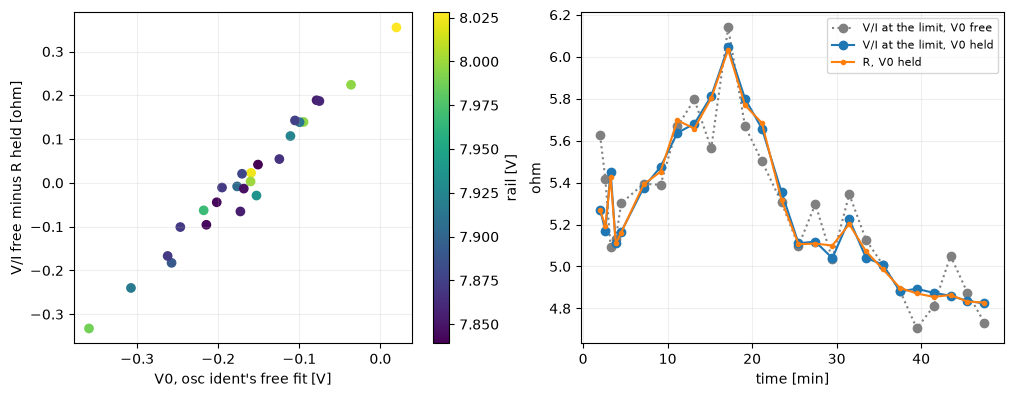

In [13]:
# Where does one burst pin its line? Along a run's V0 profile R moves -dR/dV0 for every volt of V0,
# so V = V0 + R i stays put at i* = -1 / (dR/dV0).
i_star = -1 / slopes
print(f"the line is pinned at i* = {i_star.median():.3f} A (runs {i_star.min():.3f} .. {i_star.max():.3f}); "
      f"the current limit, where V/I is read, is {I_LIM:.3f} A")

# The top rung's ON current, from the fitted model of one anchor run.
run, p = RUN[0], FREE[0]["fit"].p
_, cur = wf.simulate(run.prepared, run.model, np.tile([p[n] for n in wf.NAMES], (len(run.prepared), 1)), True)
top = [c for c in range(len(run.prepared)) if run.prepared[c].duty > 0.3]
print(f"the 39% rung ends near {np.median([cur[c, len(run.prepared[c].on) - 40] for c in top]):.3f} A, "
      f"the 25% rung near {np.median([cur[c, len(run.prepared[c].on) - 40] for c in range(len(run.prepared)) if c not in top]):.3f} A")

X = pd.DataFrame({"one": 1.0, "R held": RUNS.r, "V0 free": RUNS.v0_free, "rail": RUNS.rail_v})
rows = []
for cols in (["one", "R held"], ["one", "V0 free"], ["one", "rail"], ["one", "R held", "V0 free"],
             ["one", "R held", "V0 free", "rail"]):
    coef, *_ = np.linalg.lstsq(X[cols], RUNS.vi_free, rcond=None)
    res = RUNS.vi_free - X[cols] @ coef
    rows.append({"V/I free against": " + ".join(cols[1:]), **{c: coef[i] for i, c in enumerate(cols) if c != "one"},
                 "rms left [ohm]": np.sqrt(np.mean(res ** 2))})
display(pd.DataFrame(rows).set_index("V/I free against").round(3))
print(f"V/I free: sd {RUNS.vi_free.std():.3f} ohm over all runs; V/I with V0 held minus R held: "
      f"{(RUNS.vi - RUNS.r).mean():.3f} +/- {(RUNS.vi - RUNS.r).std():.3f} ohm")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.3))
sc_ = a1.scatter(RUNS.v0_free, RUNS.vi_free - RUNS.r, c=RUNS.rail_v, cmap="viridis")
a1.set_xlabel("V0, osc ident's free fit [V]")
a1.set_ylabel("V/I free minus R held [ohm]")
plt.colorbar(sc_, ax=a1, label="rail [V]")
a2.plot(RUNS.t_s / 60, RUNS.vi_free, "o:", color="grey", label="V/I at the limit, V0 free")
a2.plot(RUNS.t_s / 60, RUNS.vi, "o-", label="V/I at the limit, V0 held")
a2.plot(RUNS.t_s / 60, RUNS.r, ".-", label="R, V0 held")
a2.set_xlabel("time [min]")
a2.set_ylabel("ohm")
a2.legend(fontsize=8)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()

**What you are looking at.** First, where each run's line is pinned. Then V/I with V0 free (what `osc
ident` printed) regressed on R with V0 held, on the free V0, and on the rail. Left plot, V/I free minus
R held against the free V0, coloured by the rail. Right, V/I and R through the evening.

Along a run's profile R falls 2.07 ohm for every volt of V0, so the line $V = V_0 + R i$ stays put at
$i^* = 1/2.07 \approx 0.48$ A. That is where the 39% rung's current ends up, 0.51 A. The burst pins
its line where its biggest current sits, which makes sense. V/I is read at 0.253 A, about half way down
to zero, so it inherits part of the V0 swing. The expected weight is $1/0.253 - 1/0.484 = 1.89$ ohm
per volt.

The regression says V/I free = 1.00 x R held + 1.80 x V0 free + a constant, with 0.024 ohm rms left.
Adding the rail gives -0.009 ohm per volt and nothing else changes. So:

- **With the temperature**, V/I moves one for one with R, through R.
- **With V0**, 1.80 ohm per volt of the free V0, close to the 1.89 the line geometry predicts. This is
  where the cold V/I scatter of 4% comes from.
- **With the rail**, nothing beyond what already goes through R. Whether R itself moves with the rail
  is the drift question from section 5, which this run cannot answer.

Held at the joint V0, V/I sits within 0.001 +/- 0.026 ohm of R. That is a coincidence of -0.17 V
landing where the bridge and the offset cancel at 0.253 A. It is not a rule.

## 9. The overnight rest series

Section 5 ended on a -5% this run could not explain. The plainest way to see what R does when nothing
changes is to change nothing. About two hours after the cool phase, I left the same servo on the same
board resting at mid travel overnight, torque off with the driver asleep, and ran one `osc ident burst`
every 30 minutes from 22:54 to 07:06. Every fourth slot ran the wide rungs (10, 15, 25 and 40%)
instead of the default 25 and 40%, to see whether more rungs pin V0 better. The can NTC and the rail
were logged every minute between runs. The dataset is `mg90-a__dev-v006-2A__2s__rest`, from
`captures/winding-r/overnight.py` in the bringup repo.

The first four runs come from four starts of the driver, stopped to change its battery floor, so they
sit 8, 2 and 1 minutes apart. The rest are 30 minutes apart. The room's AC cycled all night and the
2S pack (450 mAh) sagged slowly, so the can and the rail both drift a little.

20 runs over 8.2 h: 8 wide (10/15/25/40%), 12 std (25/40%); the first gaps 486, 118, 70 s, then 1759 .. 1823 s
can 25.65 .. 28.22 C in the minute log, 25.99 .. 28.08 C at the runs; rail at rest 7.75 -> 7.38 V
osc ident's R 4.856 +/- 0.104 ohm (2.1%), V0 -0.194 +/- 0.045 V, corr(R, V0) -0.94


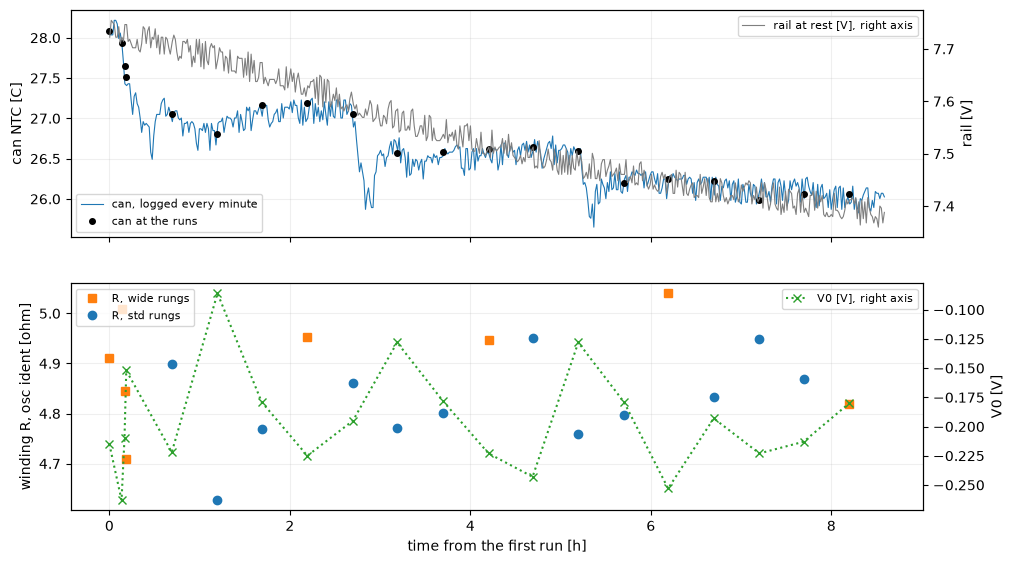

In [14]:
# The overnight rest series: one osc ident burst every 30 minutes, the servo at mid travel with
# torque off and nothing heating it. The can NTC and the rail are logged every minute between runs.
from oscnb import thermal

DSN = oscnb.datasets.ROOT / "mg90-a__dev-v006-2A__2s__rest"
NIGHT = pd.read_csv(DSN / "runs.csv")
AMB = pd.read_csv(DSN / "ambient.csv.gz")
NIGHT["can"] = thermal.ntc_c((NIGHT.ntc_raw_before + NIGHT.ntc_raw_after) / 2)
NIGHT["rail"] = board.vsys_v(NIGHT.vbus_raw)
AMB["can"] = thermal.ntc_c(AMB.ntc_raw)
AMB["rail"] = board.vsys_v(AMB.vbus_raw)
WIDE = NIGHT.kind == "wide"

gaps = NIGHT.t_s.diff().iloc[1:]
print(f"{len(NIGHT)} runs over {NIGHT.t_s.max() / 3600:.1f} h: {WIDE.sum()} wide (10/15/25/40%), "
      f"{(~WIDE).sum()} std (25/40%); the first gaps {', '.join(f'{g:.0f}' for g in gaps.iloc[:3])} s, "
      f"then {gaps.iloc[3:].min():.0f} .. {gaps.iloc[3:].max():.0f} s")
print(f"can {AMB.can.min():.2f} .. {AMB.can.max():.2f} C in the minute log, {NIGHT.can.min():.2f} .. "
      f"{NIGHT.can.max():.2f} C at the runs; rail at rest {NIGHT.rail.iloc[0]:.2f} -> {NIGHT.rail.iloc[-1]:.2f} V")
r, v = NIGHT.wave_r_ohm, NIGHT.v0_v
print(f"osc ident's R {r.mean():.3f} +/- {r.std():.3f} ohm ({r.std() / r.mean() * 100:.1f}%), "
      f"V0 {v.mean():+.3f} +/- {v.std():.3f} V, corr(R, V0) {np.corrcoef(r, v)[0, 1]:+.2f}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
a1.plot(AMB.t_s / 3600, AMB.can, "-", lw=0.8, label="can, logged every minute")
a1.plot(NIGHT.t_s / 3600, NIGHT.can, "ko", ms=4, label="can at the runs")
a1.set_ylabel("can NTC [C]")
a1b = a1.twinx()
a1b.plot(AMB.t_s / 3600, AMB.rail, "-", color="tab:grey", lw=0.8, label="rail at rest [V], right axis")
a1b.set_ylabel("rail [V]")
a1.legend(loc="lower left", fontsize=8)
a1b.legend(loc="upper right", fontsize=8)
for kind, mk, col in (("wide", "s", "tab:orange"), ("std", "o", "tab:blue")):
    g = NIGHT[NIGHT.kind == kind]
    a2.plot(g.t_s / 3600, g.wave_r_ohm, mk, color=col, label=f"R, {kind} rungs")
a2.set_ylabel("winding R, osc ident [ohm]")
a2b = a2.twinx()
a2b.plot(NIGHT.t_s / 3600, NIGHT.v0_v, "x:", color="tab:green", label="V0 [V], right axis")
a2b.set_ylabel("V0 [V]")
a2.legend(loc="upper left", fontsize=8)
a2b.legend(loc="upper right", fontsize=8)
a2.set_xlabel("time from the first run [h]")
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()


**What you are looking at.** Top, the can in the minute log and at each run, with the rail at rest on
the right axis. Bottom, the R and V0 that `osc ident` printed for each run.

The can drifts from 28.1 to 26.0 C over 8.2 hours, in steps where the AC kicks in, and the rail sags
from 7.75 to 7.38 V. Nothing heats the motor, so at each run the winding should sit at the can's
temperature.

R still scatters 2.1%, 4.856 +/- 0.104 ohm, about 5.5 C of copper. V0 swings -0.26 to -0.09 V and
moves against R, with a correlation of -0.94. That is section 3's R-V0 trade again, on runs where the
temperature barely moves.

The first four runs show it plainly. Over 3 minutes they read 5.009, 4.844 and 4.709 ohm after the
first's 4.911, a 6% fall, while V0 climbs from -0.26 to -0.15 V.

In [15]:
# The port on the overnight runs, ident's sequence with nothing held, against what osc ident printed.
# A wide run has 16 captures from rest; the 10% rung's 4 have too few ON windows to split, in
# both fits, so 12 go in.
def load_night(k):
    paths = sorted((DSN / "burst" / NIGHT.capture[k]).glob("burst-*.csv.gz"),
                   key=lambda p: int(p.name.split("-")[1].split(".")[0]))
    caps = [wf.Capture.read(p, int(p.name.split("-")[1].split(".")[0])) for p in paths]
    return wf.Run.build(caps, SC)


NRUN = {k: load_night(k) for k in NIGHT.k}
NFREE = {k: run.fit_like_ident()[0] for k, run in NRUN.items()}
PORTN = pd.DataFrame({"kind": NIGHT.kind, "split": [len(NRUN[k].prepared) for k in NIGHT.k],
                      "pooled": [NFREE[k].captures for k in NIGHT.k],
                      "R here": [NFREE[k].p["r"] for k in NIGHT.k], "R osc": NIGHT.wave_r_ohm,
                      "V0 here": [NFREE[k].p["v0"] for k in NIGHT.k], "V0 osc": NIGHT.v0_v}, index=NIGHT.k)
display(PORTN.round(3).T)
for q in ("R", "V0"):
    d = (PORTN[f"{q} here"] - PORTN[f"{q} osc"]).abs()
    print(f"{q:>3}: port against osc ident, median |diff| {d.median():.4f}, worst {d.max():.4f} (run {d.idxmax()})")


k,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
kind,wide,wide,wide,wide,std,std,std,wide,std,std,std,wide,std,std,std,wide,std,std,std,wide
split,12,12,12,12,16,16,16,12,16,16,16,12,16,16,16,12,16,16,16,12
pooled,12,12,11,12,16,15,16,12,16,16,16,12,15,16,16,12,15,15,16,12
R here,4.911,5.011,4.854,4.709,4.903,4.625,4.77,4.956,4.863,4.772,4.803,4.948,4.952,4.777,4.799,5.046,4.832,4.953,4.87,4.819
R osc,4.911,5.009,4.844,4.709,4.898,4.627,4.77,4.952,4.861,4.772,4.801,4.947,4.951,4.759,4.798,5.04,4.832,4.949,4.868,4.82
V0 here,-0.215,-0.264,-0.213,-0.151,-0.225,-0.086,-0.179,-0.226,-0.195,-0.128,-0.178,-0.223,-0.243,-0.139,-0.179,-0.256,-0.193,-0.225,-0.214,-0.18
V0 osc,-0.215,-0.263,-0.21,-0.152,-0.222,-0.086,-0.179,-0.225,-0.195,-0.128,-0.178,-0.223,-0.243,-0.128,-0.179,-0.253,-0.193,-0.223,-0.213,-0.18


  R: port against osc ident, median |diff| 0.0016, worst 0.0179 (run 13)
 V0: port against osc ident, median |diff| 0.0004, worst 0.0114 (run 13)


**What you are looking at.** The port against what `osc ident` printed, every overnight run. `split`
counts the from-rest captures whose ON windows could be placed, `pooled` the ones left in the second
pooled fit after the low ones are set aside.

They agree to a median of 0.002 ohm, 0.018 at worst (run 13), so the port reads the wide rungs the
way the Rust fit does too. In every wide run the 10% rung's ON windows are too short to place, so
both drop those four captures and fit the other 12.

## 10. The R-V0 ridge, projected out

Section 3 showed that inside one run R and V0 trade along a line. If the night's scatter is that
trade, the runs' free (V0, R) points should lie along a line of about the same slope, and moving every
run along it to one V0 should leave little. There are three ways to move them. Refit with V0 held at
a reference, section 4's recipe. Or project along a straight line, with either the slope across the
runs or each run's own slope from holding V0 on a grid. The reference is the night's mean free V0,
-0.194 V. I call R at the reference **Rc**.

across the runs: R = 4.432 -2.18 x V0 ohm, corr -0.94
inside each run (V0 held on the grid): dR/dV0 median -1.99 ohm/V, std runs -2.02 .. -1.90, wide runs -2.23 .. -1.98


,mean ohm,sd ohm,sd %,sd as copper C,wide minus std ohm
R,,,,,
"osc ident, V0 free",4.856,0.104,2.132,5.468,0.080
Rc: refit with V0 held at -0.194,4.854,0.033,0.688,1.765,0.010
moved along the ridge across runs,4.855,0.034,0.708,1.816,0.005
moved along each run's own slope,4.854,0.034,0.708,1.816,0.011


formal sd of one run's Rc (median over runs): 0.034 ohm


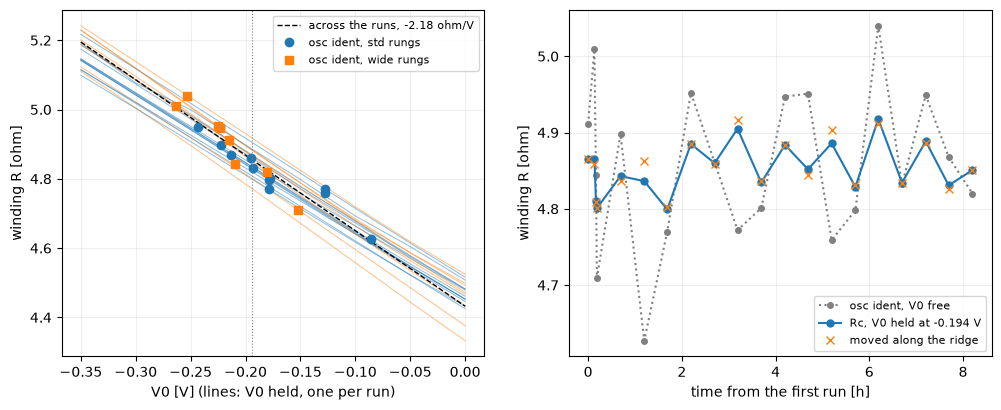

In [16]:
# Hold V0 on a grid in every overnight run and let the rest move, the way section 3 does.
V0_GRID_N = np.round(np.arange(-0.35, 0.001, 0.05), 3)
rows = []
for k, run in NRUN.items():
    start = [NFREE[k].p[n] for n in wf.NAMES]
    for v0 in V0_GRID_N:
        f = run.fit({"v0": v0}, start=start)
        rows.append({"k": k, "v0": v0, "r": f.p["r"], "cost": f.cost})
PROFN = pd.DataFrame(rows)
NIGHT["own_slope"] = PROFN.groupby("k").apply(lambda g: np.polyfit(g.v0, g.r, 1)[0], include_groups=False)

# The ridge across the runs, from osc ident's free R and V0, and the reference V0: the night's mean.
RIDGE, RIDGE_B, RIDGE_CORR = thermal.ridge(NIGHT.wave_r_ohm, NIGHT.v0_v)
V0_REF = round(NIGHT.v0_v.mean(), 3)


# Rc: ident's own sequence with V0 held at the reference, as section 4 does at its joint V0.
NHELD = {k: NRUN[k].fit_like_ident({"v0": V0_REF})[0] for k in NIGHT.k}
NIGHT["rc"] = [NHELD[k].p["r"] for k in NIGHT.k]
NIGHT["rc_ridge"] = thermal.project(NIGHT.wave_r_ohm, NIGHT.v0_v, V0_REF, RIDGE)
NIGHT["rc_own"] = thermal.project(NIGHT.wave_r_ohm, NIGHT.v0_v, V0_REF, NIGHT.own_slope)
print(f"across the runs: R = {RIDGE_B:.3f} {RIDGE:+.2f} x V0 ohm, corr {RIDGE_CORR:+.2f}")
print(f"inside each run (V0 held on the grid): dR/dV0 median {NIGHT.own_slope.median():.2f} ohm/V, "
      f"std runs {NIGHT.own_slope[~WIDE].min():.2f} .. {NIGHT.own_slope[~WIDE].max():.2f}, "
      f"wide runs {NIGHT.own_slope[WIDE].min():.2f} .. {NIGHT.own_slope[WIDE].max():.2f}")
rows = []
for name, col in (("osc ident, V0 free", "wave_r_ohm"), (f"Rc: refit with V0 held at {V0_REF:+.3f}", "rc"),
                  ("moved along the ridge across runs", "rc_ridge"), ("moved along each run's own slope", "rc_own")):
    x = NIGHT[col]
    rows.append({"R": name, "mean ohm": x.mean(), "sd ohm": x.std(), "sd %": x.std() / x.mean() * 100,
                 "sd as copper C": x.std() / x.mean() / ALPHA_CU,
                 "wide minus std ohm": x[WIDE].mean() - x[~WIDE].mean()})
display(pd.DataFrame(rows).set_index("R").round(3))
print(f"formal sd of one run's Rc (median over runs): {np.median([f.sd['r'] for f in NHELD.values()]):.3f} ohm")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for k, g in PROFN.groupby("k"):
    a1.plot(g.v0, g.r, "-", lw=0.7, color="tab:orange" if WIDE[k] else "tab:blue", alpha=0.5)
x = np.array([-0.35, 0.0])
a1.plot(x, RIDGE_B + RIDGE * x, "k--", lw=1, label=f"across the runs, {RIDGE:+.2f} ohm/V")
a1.plot(NIGHT.v0_v[~WIDE], NIGHT.wave_r_ohm[~WIDE], "o", color="tab:blue", label="osc ident, std rungs")
a1.plot(NIGHT.v0_v[WIDE], NIGHT.wave_r_ohm[WIDE], "s", color="tab:orange", label="osc ident, wide rungs")
a1.axvline(V0_REF, color="grey", lw=0.8, ls=":")
a1.set_xlabel("V0 [V] (lines: V0 held, one per run)")
a1.set_ylabel("winding R [ohm]")
a1.legend(fontsize=8)
a2.plot(NIGHT.t_s / 3600, NIGHT.wave_r_ohm, "o:", ms=4, color="grey", label="osc ident, V0 free")
a2.plot(NIGHT.t_s / 3600, NIGHT.rc, "o-", ms=5, label=f"Rc, V0 held at {V0_REF:+.3f} V")
a2.plot(NIGHT.t_s / 3600, NIGHT.rc_ridge, "x", label="moved along the ridge")
a2.set_xlabel("time from the first run [h]")
a2.set_ylabel("winding R [ohm]")
a2.legend(fontsize=8)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()


**What you are looking at.** Left, each run's R with V0 held on a grid (thin lines, orange for the
wide rungs), the free result `osc ident` printed (points), and the straight line through those points
(dashed). Right, R through the night, free and as Rc.

The free points lie along a line of -2.18 ohm/V. Inside each run, holding V0 on a grid, the fit trades
-1.99 ohm/V (-1.90 to -2.02 on the std rungs, a little steeper at -1.98 to -2.23 on the wide ones), and
section 3 found -2.07 on the evening. The two slopes are close, so the night's scatter is the fit
sliding along its own ridge, not the motor.

Taken out, all three ways land in the same place:

- **Refit with V0 held at -0.194 V (Rc)** leaves 0.033 ohm, 0.69%, about 1.8 C of copper.
- **Moved along the line across the runs** leaves 0.034 ohm. This one picks its slope from the scatter
  itself, so it is a floor by construction.
- **Moved along each run's own slope** leaves 0.034 ohm, with nothing taken from the scatter.

0.033 ohm is the fit's own standard error for one run, 0.034. So at rest, with V0 held, R repeats as
well as the fit says it can. Section 4 found three times that on the evening's anchor, and section 11
comes back to why.

The wide rungs read 0.010 ohm over the std ones, well inside the scatter. They did not pin V0 any
better (their free V0 spreads 0.036 V, the std runs' 0.046) and they did not break the ridge.

In [17]:
# What is left of Rc, against everything that changed over the night. With 20 runs a correlation
# needs |r| > 0.44 to clear the 5% level on its own.
X = pd.DataFrame({"rail [V]": NIGHT.rail, "time [h]": NIGHT.t_s / 3600, "can [C]": NIGHT.can,
                  "wide rungs (0/1)": WIDE.astype(float), "first four, 1-8 min apart (0/1)": (NIGHT.k < 4).astype(float)})
rows = []
for name, x in X.items():
    b, cov = np.polyfit(x, NIGHT.rc, 1, cov=True)
    rows.append({"Rc against": name, "corr": np.corrcoef(x, NIGHT.rc)[0, 1],
                 "slope [ohm per unit]": b[0], "slope sd": np.sqrt(cov[0, 0])})
display(pd.DataFrame(rows).set_index("Rc against").round(4))
print("the drivers against each other:")
display(X[["rail [V]", "time [h]", "can [C]"]].corr().round(2))
b, cov = np.polyfit(NIGHT.can, NIGHT.rc, 1, cov=True)
rc_m = NIGHT.rc.mean()
print(f"Rc against the can: {b[0] / rc_m * 100:+.2f} +/- {np.sqrt(cov[0, 0]) / rc_m * 100:.2f} %/C over "
      f"{NIGHT.can.max() - NIGHT.can.min():.1f} C of can; copper is +{ALPHA_CU * 100:.2f} %/C, "
      f"{ALPHA_CU * (NIGHT.can.max() - NIGHT.can.min()) * rc_m:.3f} ohm over that span")
display(NIGHT.loc[:4, ["k", "start", "kind", "t_s", "can", "wave_r_ohm", "v0_v", "rc"]].set_index("k").round(3).T)


,corr,slope [ohm per unit],slope sd
Rc against,,,
rail [V],-0.3235,-0.0849,0.0585
time [h],0.2792,0.0034,0.0027
can [C],-0.2317,-0.0123,0.0122
wide rungs (0/1),0.1517,0.0101,0.0155
"first four, 1-8 min apart (0/1)",-0.2816,-0.0229,0.0184


the drivers against each other:


,rail [V],time [h],can [C]
rail [V],1.00,-0.99,0.92
time [h],-0.99,1.00,-0.92
can [C],0.92,-0.92,1.00


Rc against the can: -0.25 +/- 0.25 %/C over 2.1 C of can; copper is +0.39 %/C, 0.040 ohm over that span


k,0,1,2,3,4
start,1,2,3,4,4
kind,wide,wide,wide,wide,std
t_s,0.0,485.7,603.8,673.8,2490.3
can,28.081,27.934,27.653,27.507,27.06
wave_r_ohm,4.911,5.009,4.844,4.709,4.898
v0_v,-0.215,-0.263,-0.21,-0.152,-0.222
rc,4.866,4.866,4.81,4.801,4.843


**What you are looking at.** Rc regressed on everything that changed through the night, one at a time.
Then how those drivers move together, and the first five runs.

Nothing clears the 5% level, which needs |r| over 0.44 with 20 runs. The rail, the clock and the can
give |r| of 0.23 to 0.32, the wide rungs 0.15, and the first four runs 0.28.

- **The first four runs.** Their free R fell 5.009, 4.844, 4.709 ohm over 3 minutes. As Rc that is
  4.866, 4.810, 4.801. Most of the fall was the ridge. What is left, 0.065 ohm, is two standard
  deviations of one run, with the can 0.4 C cooler. The close spacing shows nothing beyond that.
- **The rail, the clock and the can** all moved together (|r| 0.92 to 0.99). Even a real effect of one
  could not be told from the others here.
- **The temperature coefficient is not resolved.** Over the night's 2.1 C the slope is -0.25 +/- 0.25
  %/C. Copper's +0.39 %/C would be 0.040 ohm over that span, about one standard deviation of a single
  run. Taken at face value the slope sits 2.6 standard errors under copper, but the can fell with the
  rail, and an R that rose 0.18 ohm per volt of sag would hide copper completely. This set cannot tell
  them apart.

## 11. The evening re-read

The night gives an R at rest at a known can temperature, measured the same way as everything else
here. So read the evening against the night instead of against its own anchor. Every evening run is
refitted with V0 held at the night's reference, and Rc turns into a winding temperature through copper,
anchored at the night's mean Rc and mean can temperature.

This leans on the V0 offset being the same in both sessions, which the second cell checks as far as
the data allows. It also leans on copper, which section 10 could not check.

One physical fact frames the reading. The MG90's winding is on the rotor. Its heat reaches the magnets
and the can only across the air gap, and through the shaft and bearings. The can NTC reads the can, and
the winding can sit well above it.

reference: Rc 4.854 ohm at the can's 26.81 C (the night), V0 held at -0.194 V, copper


k,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
phase,A,A,A,A,A,B,B,B,B,B,...,C,C,C,C,C,C,C,C,C,C
t_s,120.5,157.7,195.0,231.9,270.2,429.6,549.6,669.6,789.6,909.6,...,1769.4,1889.3,2008.9,2128.6,2249.3,2369.0,2488.8,2608.7,2728.8,2849.0
can_c,28.86,28.82,28.79,28.78,28.85,36.22,38.53,39.18,39.37,38.18,...,27.72,27.61,27.53,27.34,27.42,27.12,27.12,27.02,26.71,27.22
v0_free,0.02,-0.04,-0.36,-0.16,-0.09,-0.16,-0.22,-0.15,-0.1,-0.31,...,-0.17,-0.11,-0.12,-0.17,-0.17,-0.26,-0.2,-0.08,-0.15,-0.21
r,5.27,5.19,5.43,5.11,5.16,5.39,5.45,5.7,5.66,5.8,...,5.1,5.2,5.07,4.99,4.9,4.87,4.85,4.86,4.83,4.83
rc,5.32,5.27,5.48,5.16,5.21,5.44,5.5,5.75,5.71,5.85,...,5.15,5.25,5.12,5.04,4.94,4.92,4.9,4.91,4.88,4.87
t_wind,51.45,49.0,59.68,42.74,45.8,57.9,61.17,74.14,72.22,79.65,...,42.33,47.83,40.96,36.39,31.57,30.17,29.38,29.81,28.18,27.88
over_can,22.59,20.18,30.89,13.96,16.95,21.68,22.64,34.96,32.85,41.47,...,14.61,20.22,13.43,9.05,4.15,3.05,2.26,2.79,1.47,0.66


    A, the anchor: winding over the can +14.0 .. +30.9 C (mean +20.9), Rc 5.288 ohm
      B, the heat: winding over the can +21.7 .. +53.0 C (mean +35.0), Rc 5.739 ohm
     C, first run: winding over the can +22.1 .. +22.1 C (mean +22.1), Rc 5.365 ohm
 C, the last five: winding over the can  +0.7 ..  +3.0 C (mean  +2.0), Rc 4.897 ohm
heater: 0.418 .. 0.420 A rms x Rc 5.44 .. 6.09 ohm = 0.96 .. 1.06 W
winding over the can in the cool, all 13 cool runs: 26.7 C at the heat's end, tau 720 +/- 157 s, rms 3.5 C
winding over the can in the cool, without the first: 26.3 C at the heat's end, tau 731 +/- 207 s, rms 3.6 C


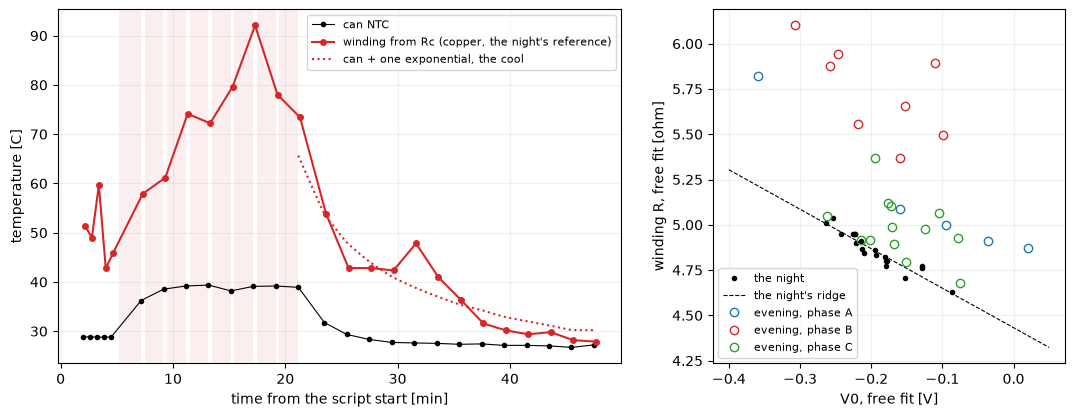

In [18]:
# The evening's runs refitted with V0 held at the night's reference, the same recipe as Rc.
RUNS["rc"] = [RUN[k].fit_like_ident({"v0": V0_REF})[0].p["r"] for k in RUNS.k]
R_REF, T_REF = NIGHT.rc.mean(), NIGHT.can.mean()      # the night's Rc at the night's mean can
RUNS["t_wind"] = thermal.copper_c(RUNS.rc, R_REF, T_REF)
RUNS["over_can"] = RUNS.t_wind - RUNS.can_c
print(f"reference: Rc {R_REF:.3f} ohm at the can's {T_REF:.2f} C (the night), V0 held at {V0_REF:+.3f} V, copper")
display(RUNS[["k", "phase", "t_s", "can_c", "v0_free", "r", "rc", "t_wind", "over_can"]].set_index("k").round(2).T)
for name, sel in (("A, the anchor", RUNS.phase == "A"), ("B, the heat", RUNS.phase == "B"),
                  ("C, first run", RUNS.k == 13), ("C, the last five", RUNS.k >= 21)):
    g = RUNS[sel]
    print(f"{name:>17}: winding over the can {g.over_can.min():+5.1f} .. {g.over_can.max():+5.1f} C "
          f"(mean {g.over_can.mean():+5.1f}), Rc {g.rc.mean():.3f} ohm")

# The heater's power: the rms current from heater.csv, times the winding R the next run reads.
nxt = [RUNS.rc[RUNS.t_s > e].iloc[0] for e in HEAT.end_s]
HEAT["watts"] = HEAT.i_rms_A ** 2 * np.array(nxt)
print(f"heater: {HEAT.i_rms_A.min():.3f} .. {HEAT.i_rms_A.max():.3f} A rms x Rc {min(nxt):.2f} .. {max(nxt):.2f} ohm "
      f"= {HEAT.watts.min():.2f} .. {HEAT.watts.max():.2f} W")

# The excess in the cool: one exponential toward zero from the heat's end.
CL = RUNS[RUNS.phase == "C"]
tcool = (CL.t_s + CAP_LAG - HEAT.end_s.iloc[-1]).to_numpy()
EXP = {}
for name, m in (("all 13 cool runs", np.ones(len(CL), bool)), ("without the first", tcool > 200)):
    s = least_squares(lambda q: q[0] * np.exp(-tcool[m] / q[1]) - CL.over_can.to_numpy()[m], [20, 500])
    cov = np.linalg.pinv(s.jac.T @ s.jac) * (s.fun @ s.fun) / (m.sum() - 2)
    EXP[name] = s.x
    print(f"winding over the can in the cool, {name}: {s.x[0]:.1f} C at the heat's end, tau {s.x[1]:.0f} "
          f"+/- {np.sqrt(cov[1, 1]):.0f} s, rms {np.sqrt(np.mean(s.fun ** 2)):.1f} C")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
for _, w in HEAT.iterrows():
    a1.axvspan(w.start_s / 60, w.end_s / 60, color="tab:red", alpha=0.08, lw=0)
a1.plot(RUNS.t_s / 60, RUNS.can_c, "ko-", ms=3, lw=0.8, label="can NTC")
a1.plot((RUNS.t_s + CAP_LAG) / 60, RUNS.t_wind, "o-", color="tab:red", ms=4, label="winding from Rc (copper, the night's reference)")
tt = np.linspace(0, tcool.max(), 100)
a1.plot((tt + HEAT.end_s.iloc[-1]) / 60, np.interp(tt + HEAT.end_s.iloc[-1], RUNS.t_s, RUNS.can_c) + EXP["all 13 cool runs"][0]
        * np.exp(-tt / EXP["all 13 cool runs"][1]), ":", color="tab:red", label="can + one exponential, the cool")
a1.set_xlabel("time from the script start [min]")
a1.set_ylabel("temperature [C]")
a1.legend(fontsize=8)
a2.plot(NIGHT.v0_v, NIGHT.wave_r_ohm, "k.", label="the night")
x = np.array([-0.4, 0.05])
a2.plot(x, RIDGE_B + RIDGE * x, "k--", lw=0.8, label="the night's ridge")
for ph, col in (("A", "tab:blue"), ("B", "tab:red"), ("C", "tab:green")):
    g = RUNS[RUNS.phase == ph]
    a2.plot(g.v0_free, g.r_free, "o", color=col, mfc="none", label=f"evening, phase {ph}")
a2.set_xlabel("V0, free fit [V]")
a2.set_ylabel("winding R, free fit [ohm]")
a2.legend(fontsize=8)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.show()


**What you are looking at.** The table is every evening run with V0 held at the night's reference: Rc,
the winding temperature it implies through copper, and that minus the can. The plot, left, is the can
and that winding temperature through the evening, with one exponential fitted to the cool. Right, the
free (V0, R) of every run, the night's along its ridge, the evening's by phase.

Read this way the evening makes physical sense:

- **The end of the cool lands on the night.** The last five runs read Rc 4.897 ohm, 0.043 over the
  night's 4.854, about 2 C over their can. The 5.7% fall that section 5 could not explain is the
  winding coming down to the can.
- **The heat.** At 0.96 to 1.06 W (0.418 to 0.420 A rms through Rc of 5.44 to 6.09 ohm), the winding
  reads 22 to 53 C over the can.
- **The cool.** The first cool run reads 22 C over a can that has already dropped to 31.8 C. From
  there the excess decays with a time constant of 720 +/- 157 s, one exponential toward zero, 3.5 C
  rms. Leaving the first cool run out gives 731 +/- 207 s. Section 6's 19 s winding node cannot do
  this.
- **The anchor** reads 14 to 31 C over its can. It was not a cold anchor. The next cell asks whether
  that is real or a V0 offset.

The heat runs scatter far more than the night's 1.8 C. Run 10 reads 92 C between neighbours at
80 and 78. How long the heater has been off at the capture moves the winding, and the heat runs scatter in V0
too (-0.10 to -0.31 V), but this data does not say how much of the spread each one is.

On the right, the night's points sit on their ridge and so do the evening's last cool runs. The
anchor's points sit well above it, and the heat runs far above.

In [19]:
# Phase A against the same evening's last five runs, and against the night.
A_, LATE = RUNS[RUNS.phase == "A"], RUNS[RUNS.k >= 21]
dv_late = A_.v0_free.mean() - LATE.v0_free.mean()
dv_night = A_.v0_free.mean() - NIGHT.v0_v.mean()
print(f"can: A {A_.can_c.mean():.2f} C, the last five {LATE.can_c.mean():.2f} C ({A_.can_c.mean() - LATE.can_c.mean():+.2f}), "
      f"the night {T_REF:.2f} C")
print(f"free V0: A {A_.v0_free.mean():+.3f} +/- {A_.v0_free.std():.3f} V (runs {', '.join(f'{x:+.2f}' for x in A_.v0_free)}), "
      f"the last five {LATE.v0_free.mean():+.3f}, the night {NIGHT.v0_v.mean():+.3f}")
print(f"Rc: A {A_.rc.mean():.3f} +/- {A_.rc.std() / np.sqrt(len(A_)):.3f} ohm (se), the last five {LATE.rc.mean():.3f}, "
      f"the night {R_REF:.3f}")
print(f"if A's whole V0 shift were a true offset and not scatter along the ridge, the projection would "
      f"move A's Rc by {RIDGE * -dv_late:+.3f} ohm against the last five, {RIDGE * -dv_night:+.3f} against the night")
above = RUNS.r_free - (RIDGE_B + RIDGE * RUNS.v0_free)
print(f"free (V0, R) points above the night's ridge: A {above[RUNS.phase == 'A'].mean():+.3f} ohm, "
      f"the last five {above[RUNS.k >= 21].mean():+.3f}")
b, cov = np.polyfit(A_.t_s, A_.rc, 1, cov=True)
print(f"Rc inside A: {b[0] * 60:+.3f} +/- {np.sqrt(cov[0, 0]) * 60:.3f} ohm/min over its "
      f"{A_.t_s.max() - A_.t_s.min():.0f} s ({b[0] * 60 / R_REF / ALPHA_CU:+.1f} C/min of copper)")


can: A 28.82 C, the last five 27.04 C (+1.78), the night 26.81 C
free V0: A -0.126 +/- 0.147 V (runs +0.02, -0.04, -0.36, -0.16, -0.09), the last five -0.181, the night -0.194
Rc: A 5.288 +/- 0.055 ohm (se), the last five 4.897, the night 4.854
if A's whole V0 shift were a true offset and not scatter along the ridge, the projection would move A's Rc by +0.120 ohm against the last five, +0.149 against the night
free (V0, R) points above the night's ridge: A +0.430 ohm, the last five +0.044
Rc inside A: -0.053 +/- 0.065 ohm/min over its 150 s (-2.8 C/min of copper)


**What you are looking at.** Phase A against the evening's last five runs and against the night: the
can, the free V0, Rc, the most a V0 offset could move Rc, and how far A's free points sit above the
night's ridge.

The worry is this. Rc holds V0 at the night's value. If the true V0 offset differed between the
sessions, holding V0 would carry that difference into R at about -2 ohm/V. A's free V0 averages -0.126
V, against -0.181 for the last five runs and -0.194 for the night. Only runs 0 and 1 read near zero,
the other three -0.09 to -0.36 V.

- **If all of A's V0 difference were a true offset**, Rc would read high by 0.12 ohm against the last
  five, about 6 C. A reads 0.39 ohm over the last five, so at least 0.27 ohm, about 14 C, is not V0.
- **The free fit, with nothing held**, puts A 0.43 ohm above the night's ridge and the last five 0.04.
  The same V0 bound takes 0.15 off that, which still leaves 0.28.
- **A's can sat 1.8 C over the last five's.** The hand reading said 26.1 C for the room, under a can
  at 28.9 C.

So the anchor's R was high for a reason other than V0, by about 14 to 20 C of copper. Inside A, Rc
falls by about 0.05 ohm per minute, but over 150 s and five runs that is within one standard error,
so A does not show the cooling itself. What warmed it is not in the data. The run's notes say the
motor rested before A until the can held within 0.15 C over two minutes, and an earlier 3 minute
dither is in `heattest.log`. A can that holds still says nothing about a winding that cools over tens
of minutes.

The two sessions agree at their ends, Rc 4.897 against 4.854 ohm with V0 at -0.181 against -0.194. That
bounds any offset between these two sessions to about 0.05 ohm, 2 C. Whether a V0 offset can move more
than that between other sessions stays open.

## 12. The rotor behind the air gap

Section 6 fitted a winding that follows the can within 19 s. The re-read says the winding stays above
the can for many minutes. So refit the two-node model with the rotor in mind. Heat goes into the
winding, crosses the air gap to the can, and leaves the can to the air. The can NTC observes the can,
Rc observes the winding through copper and the night's reference.

$$C_w \frac{dT_w}{dt} = I^2 R(T_w) - \frac{T_w - T_c}{R_{wc}}, \qquad
C_c \frac{dT_c}{dt} = \frac{T_w - T_c}{R_{wc}} - \frac{T_c - T_a}{R_{ca}}$$

Eight free parameters: both heat capacities $C_w$ and $C_c$, both resistances $R_{wc}$ and $R_{ca}$,
the ambient line (start and slope), and both starting temperatures, since the anchor was not at rest.
No priors, only wide bounds, and every fit starts from four places and keeps the best. The model steps
exactly from event to event (`oscnb.thermal.TwoNode`), so there is no step size to worry about. The
coefficient is copper's unless a row says otherwise.

The weights decide what a fit believes. The can is weighed at 0.1 C. For Rc there are two honest
choices, the evening's cold scatter of 0.10 ohm (section 4) or the night's 0.033 (section 10). A third
fit trusts Rc and loosens the can to 2 C, to see what R alone wants. Then three variants of the
rest-noise fit: the coefficient free, part of the heat landing on the can directly, and the anchor
left out. The uncertainties are the fit's own standard errors, and a jackknife that drops one run (its
can reads and its Rc) at a time.

In [20]:
# The rotor behind the air gap: heat into the winding, winding -> can -> air. The can NTC reads the
# can, Rc reads the winding through copper and the night's reference. Free: both heat capacities,
# both resistances, the ambient line, and both starting temperatures (phase A was not at rest).
HEAT_W = [(w.start_s, w.end_s, w.i_rms_A ** 2) for _, w in HEAT.iterrows()]
RNAMES = ["c_w", "c_c", "r_wc", "r_ca", "ta0", "tb", "tw0", "tc0"]
RQ0 = dict(c_w=2, c_c=8, r_wc=40, r_ca=12, ta0=28.9, tb=-8e-4, tw0=40, tc0=28.9, alpha=ALPHA_CU, share=1.0)
RLO = dict(c_w=0.05, c_c=0.2, r_wc=0.5, r_ca=1, ta0=20, tb=-0.01, tw0=20, tc0=20, alpha=0.0005, share=0.0)
RHI = dict(c_w=200, c_c=200, r_wc=500, r_ca=100, ta0=40, tb=0.01, tw0=90, tc0=40, alpha=0.05, share=1.0)
STARTS = [{}, dict(c_w=8, r_wc=60, tw0=48), dict(c_w=0.5, r_wc=50, tw0=30), dict(c_w=4, c_c=3, r_wc=50, tw0=50)]
SIG_NIGHT = NIGHT.rc.std()                    # one run's Rc at rest, the night's scatter


def rotor(p, t_can, t_r):
    net = thermal.TwoNode(p["c_w"], p["c_c"], p["r_wc"], p["r_ca"], p["share"])
    tw, tc, ta = net.run(T0, (p["tw0"], p["tc0"], p["ta0"]), HEAT_W, np.r_[t_can, t_r],
                         R_REF, T_REF, p["alpha"], p["tb"])
    n = len(t_can)
    return tc[:n], thermal.copper_ohm(tw[n:], R_REF, T_REF, p["alpha"]), tw, ta


def fit_rotor(sig_c, sig_r, keep=None, extra=(), starts=STARTS):
    rr = RUNS if keep is None else RUNS[RUNS.k.isin(keep)]
    ct, cy = np.r_[rr.t_s, rr.t_s + rr.burst_s], np.r_[rr.can_before, rr.can_after]
    rt, ry = rr.t_s.to_numpy() + CAP_LAG, rr.rc.to_numpy()
    names = RNAMES + list(extra)

    def res(q):
        p = dict(RQ0, **dict(zip(names, q)))
        mc, mr, _, _ = rotor(p, ct, rt)
        return np.r_[(mc - cy) / sig_c, (mr - ry) / sig_r]

    best = None
    for st in starts:
        s = least_squares(res, [dict(RQ0, **st)[n] for n in names], x_scale="jac",
                          bounds=([RLO[n] for n in names], [RHI[n] for n in names]))
        if best is None or s.cost < best.cost:
            best = s
    p = dict(RQ0, **dict(zip(names, best.x)))
    cov = np.linalg.pinv(best.jac.T @ best.jac) * (best.fun @ best.fun) / (len(best.fun) - len(best.x))
    sd = dict(zip(names, np.sqrt(np.clip(np.diag(cov), 0, None))))
    p["tau_fast"], p["tau_slow"] = thermal.TwoNode(p["c_w"], p["c_c"], p["r_wc"], p["r_ca"]).modes()
    n = len(ct)
    p["rms_can"] = np.sqrt(np.mean((best.fun[:n] * sig_c) ** 2))
    p["rms_r"] = np.sqrt(np.mean((best.fun[n:] * sig_r) ** 2))
    return p, sd


ROTOR = {
    "can-led (0.1 C, 0.10 ohm)": fit_rotor(0.1, 0.10),
    f"rest noise (0.1 C, {SIG_NIGHT:.3f} ohm)": fit_rotor(0.1, SIG_NIGHT),
    f"R-led (2 C, {SIG_NIGHT:.3f} ohm)": fit_rotor(2.0, SIG_NIGHT),
    "rest noise, alpha free": fit_rotor(0.1, SIG_NIGHT, extra=("alpha",)),
    "rest noise, share free": fit_rotor(0.1, SIG_NIGHT, extra=("share",)),
    "rest noise, without A": fit_rotor(0.1, SIG_NIGHT, keep=list(range(5, 26))),
}
MAIN = f"rest noise (0.1 C, {SIG_NIGHT:.3f} ohm)"

# Leave one run out (its can reads and its Rc), refit from the full fit, 26 times.
p_main = ROTOR[MAIN][0]
JK = []
for k in RUNS.k:
    p, _ = fit_rotor(0.1, SIG_NIGHT, keep=[j for j in RUNS.k if j != k], starts=[{n: p_main[n] for n in RNAMES}])
    JK.append(p)
JK = pd.DataFrame(JK)
COLS = ["c_w", "r_wc", "c_c", "r_ca", "tau_fast", "tau_slow", "tw0", "tc0", "alpha", "share", "rms_can", "rms_r"]
jk_sd = {c: np.sqrt((len(JK) - 1) / len(JK) * ((JK[c] - JK[c].mean()) ** 2).sum()) for c in COLS}
rows = {}
for name, (p, sd) in ROTOR.items():
    rows[name] = {c: f"{p[c]:.4g}" + (f" +/- {sd[c]:.2g}" if c in sd else "") for c in COLS}
rows["rest noise, jackknife sd"] = {c: f"{jk_sd[c]:.2g}" for c in COLS}
display(pd.DataFrame(rows).T)
print("units: C in J/C, R in C/W, tau in s, temperatures in C, rms_can in C, rms_r in ohm; "
      "+/- is the fit's own standard error scaled by its reduced chi-square")
for name, (p, _) in ROTOR.items():
    print(f"{name:>32}: rms against the can {p['rms_can']:.2f} C, against Rc {p['rms_r']:.3f} ohm "
          f"(= {p['rms_r'] / R_REF / ALPHA_CU:.0f} C of copper)")


,c_w,r_wc,c_c,r_ca,tau_fast,tau_slow,tw0,tc0,alpha,share,rms_can,rms_r
"can-led (0.1 C, 0.10 ohm)",0.3265 +/- 0.13,54.83 +/- 9.1,9.158 +/- 0.88,11.73 +/- 0.41,17.17,112,28.87 +/- 9.7,28.77 +/- 0.25,0.0039,1,0.254,0.2568
"rest noise (0.1 C, 0.033 ohm)",1.8 +/- 0.21,45.26 +/- 3.4,1.78 +/- 0.85,12.48 +/- 0.35,16.51,109.6,30.64 +/- 2.7,28.75 +/- 0.49,0.0039,1,0.3041,0.2316
"R-led (2 C, 0.033 ohm)",4.889 +/- 0.5,51.71 +/- 2.2,154.8 +/- 6.7e+02,1.503 +/- 5.8,202.9,290,56.77 +/- 2.4,25.76 +/- 2.6,0.0039,1,2.56,0.1005
"rest noise, alpha free",3.163 +/- 12,4.646 +/- 5.8,6.112 +/- 16,12.1 +/- 0.88,9.234,117.7,29.14 +/- 2.4,28.75 +/- 0.46,0.01327 +/- 0.0017,1,0.306,0.1946
"rest noise, share free",0.5096 +/- 0.44,500 +/- 4.4e+02,8.372 +/- 1.4,13.38 +/- 0.67,107.1,266.6,59.87 +/- 4.8,28.56 +/- 0.3,0.0039,0.09416 +/- 0.081,0.4606,0.1179
"rest noise, without A",2.036 +/- 0.21,45.39 +/- 2.7,1.664 +/- 0.69,12.4 +/- 0.43,15.54,122.8,79.81 +/- 20,35.89 +/- 4,0.0039,1,0.2814,0.1682
"rest noise, jackknife sd",0.19,3.5,0.45,0.34,3.8,11,2.5,4.5,0,0,0.092,0.031


units: C in J/C, R in C/W, tau in s, temperatures in C, rms_can in C, rms_r in ohm; +/- is the fit's own standard error scaled by its reduced chi-square
       can-led (0.1 C, 0.10 ohm): rms against the can 0.25 C, against Rc 0.257 ohm (= 14 C of copper)
   rest noise (0.1 C, 0.033 ohm): rms against the can 0.30 C, against Rc 0.232 ohm (= 12 C of copper)
          R-led (2 C, 0.033 ohm): rms against the can 2.56 C, against Rc 0.101 ohm (= 5 C of copper)
          rest noise, alpha free: rms against the can 0.31 C, against Rc 0.195 ohm (= 10 C of copper)
          rest noise, share free: rms against the can 0.46 C, against Rc 0.118 ohm (= 6 C of copper)
           rest noise, without A: rms against the can 0.28 C, against Rc 0.168 ohm (= 9 C of copper)


**What you are looking at.** One fit per row, each parameter with the fit's standard error, the two
modal time constants, and the rms against the can and against Rc. The last row is the jackknife
spread of the rest-noise fit.

The model does not fit. Every weighting lands on one of two answers, and neither describes both
observables:

- **Follow the can** (can-led and rest-noise). The can fits to 0.25 to 0.30 C rms, and the modes come
  out at 17 and 110 s, section 6's picture again. But Rc misses by 0.23 to 0.26 ohm rms, about 12 C of
  copper, in the pattern the next plot shows.
- **Follow Rc** (R-led). Rc fits to 0.10 ohm, about 5 C, with a slow winding (modes 200 and 290 s) and
  $C_w$ of 4.9 J/C. But the can misses by 2.6 C rms, and $C_c$ runs off to 155 J/C with an error bar
  four times that.

The variants do not rescue it. A free coefficient runs to 1.33 +/- 0.17 %/C, 3.4 times copper, and
still misses Rc by 10 C. That is a model straining, not a measurement of the coefficient. Letting part
of the heat land on the can directly sends the winding's share to 0.09 and winding to can to its 500
C/W bound, and misses the can by 0.46 C. Leaving the anchor out still misses Rc by 9 C and runs the
starting winding to 80 C.

For the record, the rest-noise fit, which weighs each observable at its noise at rest:

| | value | fit sd | jackknife sd |
|---|---|---|---|
| $C_w$, winding | 1.80 J/C | 0.21 | 0.19 |
| $R_{wc}$, winding to can | 45.3 C/W | 3.4 | 3.5 |
| $C_c$, can | 1.78 J/C | 0.85 | 0.45 |
| $R_{ca}$, can to air | 12.5 C/W | 0.35 | 0.34 |
| fast mode | 16.5 s | | 3.8 |
| slow mode | 110 s | | 11 |

The jackknife agrees with the fit's own errors, so no single run drives the fit. The uncertainty that
matters is the spread between weightings, which is far larger: $C_c$ from 1.8 to 9.2 J/C across the
two can-following fits, $C_w$ from 0.33 to 4.9 J/C across all three. Only can to air holds, 11.7 to
12.5 C/W in the fits that follow the can, the same as section 6's 12.2. Section 6's winding to can,
34 +/- 9 C/W, and its 19 and 104 s modes come back too, because they come from the same can data.
What Rc adds is that the winding does not behave that way.

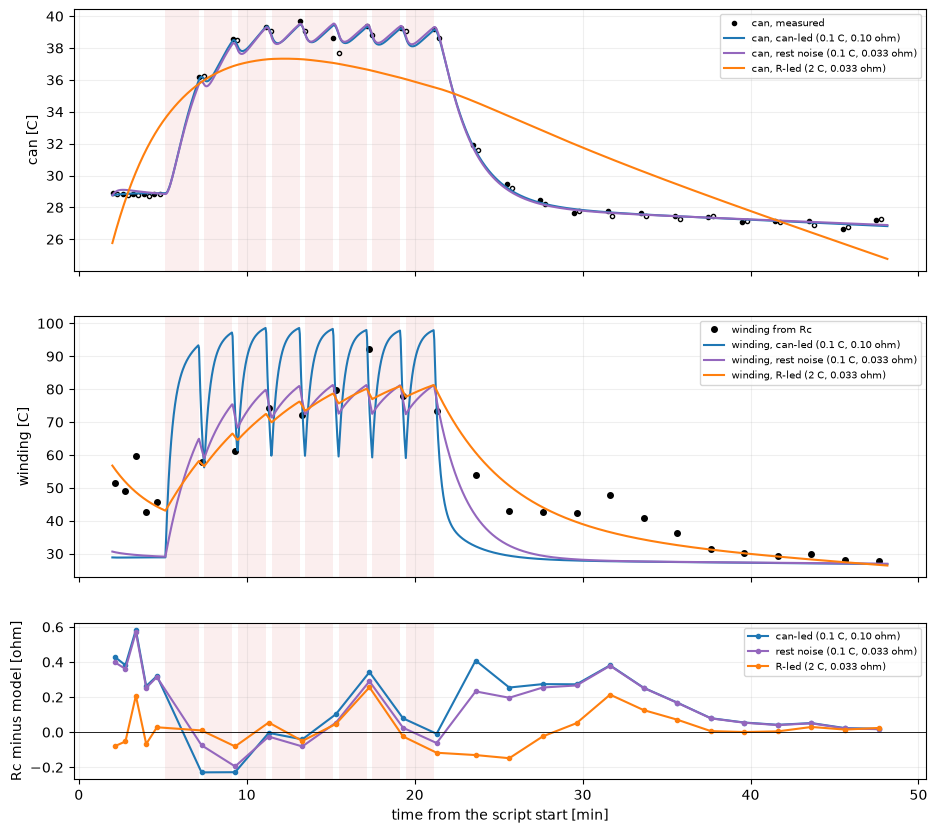

       can-led (0.1 C, 0.10 ohm): C_w 0.33 J/C = 0.8 g of copper; C_c 9.16 J/C = 19.9 g of steel
   rest noise (0.1 C, 0.033 ohm): C_w 1.80 J/C = 4.7 g of copper; C_c 1.78 J/C = 3.9 g of steel
          R-led (2 C, 0.033 ohm): C_w 4.89 J/C = 12.7 g of copper; C_c 154.82 J/C = 336.6 g of steel


In [21]:
# The fits against the data, and the Rc residual run by run.
tg = np.linspace(T0, RUNS.t_s.max() + 40, 1200)
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(11, 10), sharex=True, gridspec_kw={"height_ratios": [1, 1, 0.6]})
for _, w in HEAT.iterrows():
    for ax in (a1, a2, a3):
        ax.axvspan(w.start_s / 60, w.end_s / 60, color="tab:red", alpha=0.08, lw=0)
a1.plot(RUNS.t_s / 60, RUNS.can_before, "ko", ms=3, label="can, measured")
a1.plot((RUNS.t_s + RUNS.burst_s) / 60, RUNS.can_after, "ko", ms=3, mfc="none")
a2.plot((RUNS.t_s + CAP_LAG) / 60, RUNS.t_wind, "ko", ms=4, label="winding from Rc")
for (name, (p, _)), col in zip(list(ROTOR.items())[:3], ("tab:blue", "tab:purple", "tab:orange")):
    tc, _, tw, ta = rotor(p, tg, tg)
    a1.plot(tg / 60, tc, "-", color=col, label=f"can, {name}")
    a2.plot(tg / 60, tw[len(tg):], "-", color=col, label=f"winding, {name}")
    _, mr, _, _ = rotor(p, np.array([T0]), RUNS.t_s.to_numpy() + CAP_LAG)
    a3.plot((RUNS.t_s + CAP_LAG) / 60, RUNS.rc - mr, "o-", ms=3, color=col, label=name)
a1.set_ylabel("can [C]")
a2.set_ylabel("winding [C]")
a3.set_ylabel("Rc minus model [ohm]")
a3.axhline(0, color="k", lw=0.6)
a3.set_xlabel("time from the script start [min]")
for ax in (a1, a2, a3):
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7)
plt.show()

# What the fitted heat capacities would weigh as copper (0.385 J/g/C) or steel (0.46 J/g/C).
for name, (p, _) in list(ROTOR.items())[:3]:
    print(f"{name:>32}: C_w {p['c_w']:.2f} J/C = {p['c_w'] / 0.385:.1f} g of copper; "
          f"C_c {p['c_c']:.2f} J/C = {p['c_c'] / 0.46:.1f} g of steel")


**What you are looking at.** Top, the can measured and the three main fits. Middle, the winding each
fit implies, with the winding Rc reads. Bottom, Rc minus each fit, run by run.

The can-following fits put the winding at 80 to 98 C at the end of each heat window and back near the
can within a couple of minutes. Then they miss every cool run from 23 to 34 minutes by 0.2 to 0.4 ohm,
and the anchor by 0.25 to 0.6. The R-led fit follows the cool, but its can rises too slowly and cools
far too slowly.

No heat capacity fixes it. An MG90 rotor is a few grams of copper and iron. At 0.39 to 0.45 J/g/C,
2 to 4 g is about 1 to 2 J/C. During the heat, about 1 W lifts the winding 35 to 50 C over the can
within 15 minutes, which caps winding to can near 50 to 70 C/W. A node that decays at 720 s through
that needs 10 to 14 J/C, 27 to 37 g of copper, more than the whole servo weighs. The can-following
fits' 0.33 J/C is under a gram of copper, and the R-led fit's 4.9 J/C is already 13 g. Neither is a
rotor.

So R stays up after running for longer than a rotor on its own can hold the heat. Two candidates fit
what is here, and this data cannot separate them:

- **A third thermal mass** the winding reaches easily and the can NTC does not see, such as the shaft,
  the bearings and the metal gear train. The winding would heat it during the heat and lean on it in
  the cool.
- **A part of R that is not the winding's temperature**, such as brush and commutator contact that
  changes with running and relaxes over ten minutes or so.

The Open section lists what would tell them apart.

## What this says

**R with V0 held repeats at rest.** Overnight, with V0 held at one reference, R repeats to 0.033 ohm,
0.69%, about 1.8 C of copper, which is the fit's own error. The 2.1% scatter `osc ident` prints is the
fit sliding along its R-V0 ridge. The evening's three times larger cold scatter came from an anchor
that was not at rest.

**The evening's -5% drift is R coming back after the heat.** Against the night's R at rest, the anchor
read 14 to 31 C over its can and the last cool runs 2 C. A V0 offset between the sessions accounts for
at most 6 to 8 C of the anchor's excess.

**The winding runs 22 to 53 C over the can at about 1 W, and its excess decays with a time constant
of 720 +/- 157 s**, against about 110 s for the can. Read through copper, that is the winding. It may
also be partly R that is not temperature (section 12).

**A two-node model with the rotor behind the air gap does not fit.** It follows the can or R, never
both, and the slow decay would need a winding heat capacity of 10 to 14 J/C, several times a rotor's.
Can to air, about 12 C/W, is the one number every can-following fit agrees on.

**The temperature coefficient is still not measured.** The night's can moved 2.1 C, together with the
rail. Every temperature here assumes copper.

**V/I at the limit** follows the temperature through R, and the free V0 at 1.80 ohm per volt. The rail
adds nothing on top.

**What the data supports doing next:**

- **Rest at least an hour before a cold anchor.** The excess decays at about 720 s, five time
  constants is an hour, and a can that holds still says nothing about it.
- **Hold V0 at one reference before reading a temperature from R**, the same reference in every
  session, and anchor on R at rest read that way, not on the free R.
- **Check against the can NTC only at rest.** Under heat and for the first half hour of a cool, the
  winding is not at the can.
- **Log R densely through a cool**, a burst every 30 s for 30 minutes after a heat, to resolve the fast
  drop and the slow tail that the 2 minute spacing here only hints at.
- **Redo the stage lengths of section 7** once a model fits both the can and R.

## Caveats

- **One servo, one board, one evening and one night.** 26 runs over 46 minutes, then 20 runs over 8.2
  hours.
- **The capture timing is estimated.** Each run logs only its start. The middle of its from-rest captures
  is taken at 9 s in, and the winding cools fast enough there for that to move winding to can by
  +/-20% in section 6.
- **The heater power is the rms of a 25 Hz current poll** times R. The brushes and the gears turn some
  of the dither into heat too, and none of that is counted.
- **The ambient is fitted, not measured.** The hand reading said 26.1 C while the can sat at 28.9, so
  the can's rest temperature includes the board's own heat and whatever was left from earlier runs.
- **The re-read assumes one V0 offset across both sessions.** Their ends agree to 0.04 ohm, about 2 C.
  Nothing tests it under heat.
- **Every temperature from R assumes copper**, anchored at the night's mean can, 26.8 C. An error in
  the coefficient scales every excess over the can by the same factor.
- **The port is checked against one build of the Rust fit**, on the evening's and the night's captures.
  A change to `exp::wavefit` needs the port changed with it.
- **The stage simulation has a steady room and no drift**, and fits one node to a two-node truth that
  section 12 rejects. Its lengths are a floor at best.

## Open

- **What holds R up after running (section 12).** Candidates: (a) a third thermal mass the winding
  reaches and the can NTC does not see (shaft, bearings, gear train), (b) a part of R that is not the
  winding's temperature, such as brush and commutator contact that changes with running. What
  separates them:
  - A second NTC on the gear stack or the output bearing through a heat and cool. (a) predicts it
    warms and cools on R's 720 s. (b) predicts it follows the can.
  - A long dither at low current, a lot of running for little heat. (b) predicts R comes back slowly
    afterwards with the can barely warm. (a) predicts R follows the can.
  - Heat the servo with no running (a warm box), then cool it with bursts. Neither predicts a slow tail
    in R, so a tail here would rule out both.
- **The temperature coefficient (sections 5 and 10).** A soak with the rail held: no drive, the servo
  at two steady temperatures (a room and a warm box) for an hour each, on a bench supply so the rail
  cannot move with the temperature, and a burst run at each read with V0 held. With no heat flowing
  the winding is at the can, so R against the can gives $\alpha$ straight. Copper predicts 0.39 %/C.
  The night's -0.25 +/- 0.25 %/C leans away from copper, but its can moved with the rail.
- **R against the rail at a steady temperature.** The night cannot separate the rail from the can and
  the clock. Burst runs at rest with the bench supply stepped (7.4, 7.9 and 8.4 V) answer it directly.
- **V0 comes out negative (section 3)**, -0.19 V at rest, where a brush drop should be positive. The
  from-a-hold control in the same runs reads +0.68 to +0.75 V across both sessions. Candidates: a
  terminal-reading offset the fit absorbs as V0 (VB moves with the leg current on this board), or a
  model term missing from the ON or the OFF phase. The static grid load separates them. It has no brush drop, so a negative V0 on
  the grid points at the chain or the model.
- **Whether the V0 offset moves between sessions (section 11).** These two sessions agree to about 0.05
  ohm. The rest series repeated on another day, with a fresh pack and after an hour's rest, tests it.
  The same offset predicts the same Rc at the same can.
- **Heat runs scatter more than rest runs (section 11).** Candidates: the time since the heater
  stopped, or the hot runs' wider V0 swing. A run that holds the heater off for a fixed time before
  each burst separates them, since the first predicts the scatter drops and the second does not.
- **Run 9's can read 1 C low (section 1).** Candidates: the tape lifting off the can, or a real dip.
  Logging the can continuously through a heat phase would show whether it is a step or a dip.
- **The earlier heat test does not match the model (section 6)**, 1.4 C under at the end of the heat,
  151 s against about 110 s in the cooling. Section 12 rejects that model, so this stays open with it.
  Rerun it with the current logged as rms, from a can that has rested an hour.